<div style="background-color:#CC0000; padding:24px 32px; border-radius:8px; margin-bottom:8px;">
  <h1 style="color:white; margin:0; font-size:2em; letter-spacing:1px;">TD — Monte Carlo and Simulation</h1>
  <p style="color:#F5C6CB; margin:8px 0 0 0; font-size:1em;">ENSAE Paris &nbsp;·&nbsp; M1</p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:32px;">
  <h2 style="margin:0; font-size:1.4em;">1 &nbsp;·&nbsp; RANDU</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  <p>The LCG (linear congruential generator) RANDU is defined by:</p>
  <p style="text-align:center;"><b>x<sub>i</sub> = 65539 · x<sub>i−1</sub> mod 2<sup>31</sup></b> &nbsp;&nbsp; and &nbsp;&nbsp; <b>u<sub>i</sub> = x<sub>i</sub> / 2<sup>31</sup> ∈ (0,1)</b></p>
  <p>Note: 65539 = 2<sup>16</sup> + 3.</p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 1.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Show that <b>(u<sub>i</sub>, u<sub>i−1</sub>, u<sub>i−2</sub>)</b> always takes values on the union of 15 hyperplanes.
</div>

By definition, the RANDU multiplier is $a = 65539 = 2^{16}+3$, so $x_i = a\,x_{i-1} \pmod{2^{31}}$.

Compute $a^2 \pmod{2^{31}}$:

$$a^2 = (2^{16}+3)^2 = 2^{32} + 6\cdot 2^{16} + 9 \equiv 6\cdot 2^{16} + 9 \pmod{2^{31}},$$

since $2^{32} = 2\cdot 2^{31}\equiv 0$. Hence $x_i \equiv (6\cdot 2^{16}+9)\,x_{i-2}\pmod{2^{31}}$.

On the other hand, $6\,x_{i-1} = 6a\,x_{i-2} = (6\cdot 2^{16}+18)\,x_{i-2}\pmod{2^{31}}$.

Subtracting:

$$x_i - 6\,x_{i-1} \equiv -9\,x_{i-2} \pmod{2^{31}}.$$

Therefore there exists an integer $k$ such that

$$\boxed{x_i = 6\,x_{i-1} - 9\,x_{i-2} + k\cdot 2^{31}.}$$

Hence, by dividing by $2^{31}$, we get that:

$$u_i = 6\,u_{i-1} - 9\,u_{i-2} + k, \quad k\in\mathbb{Z},$$

or equivalently

$$u_i - 6\,u_{i-1} + 9\,u_{i-2} = k.$$

For each fixed integer $k$, this is the equation of a hyperplane in $\mathbb{R}^3$ (normal vector $(9,-6,1)$). Hence $(u_{i-2},u_{i-1},u_i)$ always lies on one of these parallel hyperplanes.

Since $u_{i-2}, u_{i-1}\in(0,1)$ we have $6\,u_{i-1}-9\,u_{i-2}\in(-9,6)$, so

$$k = u_i - (6\,u_{i-1}-9\,u_{i-2}) \in (0-6,\;1+9) = (-6,\,10).$$

The only integers in the open interval $(-6,10)$ are $k\in\{-5,-4,\ldots,8,9\}$, giving the 15 expected values.

**Conclusion:** Every triple $(u_{i-2},u_{i-1},u_i)\in(0,1)^3$ lies on the union of the 15 parallel hyperplanes

$$H_k = \{(u,v,w)\in(0,1)^3 : w - 6v + 9u = k\}, \quad k\in\{-5,-4,\ldots,9\}. \qquad\blacksquare$$

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 1.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Implement RANDU, generate 2×10<sup>4</sup> points, and do a scatter plot of <b>u<sub>i</sub></b> as a function of <b>u<sub>i−1</sub></b> for the subset of <i>i</i> such that <b>0.5 ≤ u<sub>i−1</sub> ≤ 0.51</b>. Discuss.
</div>

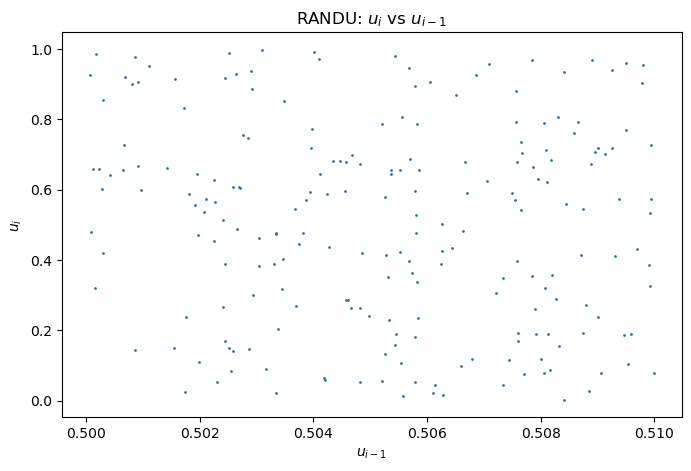

In [3]:
N = 2 * 10**4
x = 1  # odd seed to avoid that RANDU collapses
u = []
for _ in range(N):
    x = (65539 * x) % (2**31)
    u.append(x / 2**31)

# scatter u_i vs u_{i-1} for 0.5 <= u_{i-1} <= 0.51
ui_prev = [u[i-1] for i in range(1, N) if 0.5 <= u[i-1] <= 0.51]
ui      = [u[i]   for i in range(1, N) if 0.5 <= u[i-1] <= 0.51]

plt.scatter(ui_prev, ui, s=1) # s = 1 to make the dots small
plt.xlabel(r'$u_{i-1}$')
plt.ylabel(r'$u_i$')
plt.title('RANDU: $u_i$ vs $u_{i-1}$')
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 1.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Do a 3D plot of the triples <b>(u<sub>i</sub>, u<sub>i−1</sub>, u<sub>i−2</sub>)</b> to illustrate the hyperplane phenomenon.
</div>

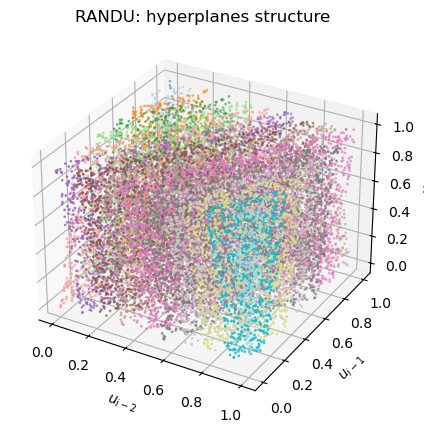

In [83]:
ui2, ui1, ui = np.array(u[:-2]), np.array(u[1:-1]), np.array(u[2:])
k_vals = np.round(9*ui2 - 6*ui1 + ui).astype(int)  # which hyperplane: -5 to 9

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(ui2, ui1, ui, c=k_vals, cmap='tab20', s=1)
ax.set_xlabel(r'$u_{i-2}$')
ax.set_ylabel(r'$u_{i-1}$')
ax.set_zlabel(r'$u_i$')
ax.set_title('RANDU: hyperplanes structure')
plt.savefig('img/randu_hyperplanes.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 1.4</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Illustrate the poor behaviour of the <b>least significant bits</b> of RANDU.
</div>

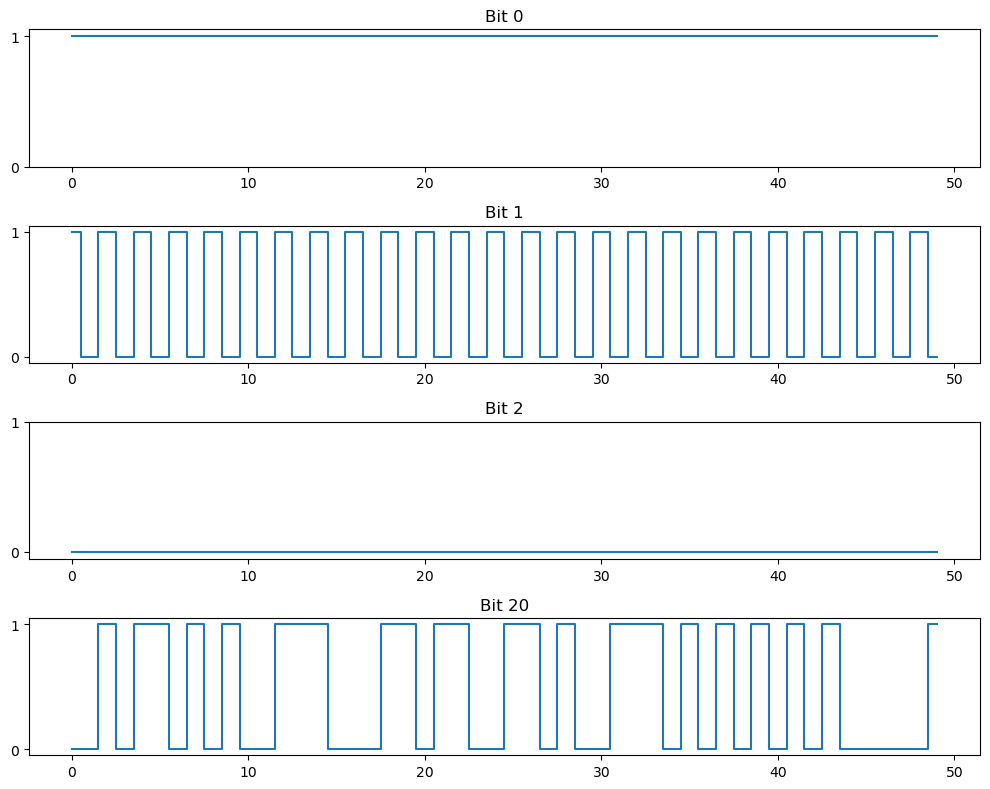

In [16]:
N, x = 2 * 10**4, 1
L = []
for _ in range(N):
    x = (65539 * x) % (2**31)
    L.append(x)

fig, axes = plt.subplots(4, 1, figsize=(10, 8))
for k, ax in zip([0, 1, 2, 20], axes): # to pair 2 lists element by element 
    bits = [(xi >> k) & 1 for xi in L[:50]]  # that's enough values to notice the pattern
    ax.plot(bits, drawstyle='steps-mid') # horizontal instead of diagonal lines to link dots
    ax.set_title(f'Bit {k}')
    ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()      

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 1.5</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
If time permits, compare the default Python generator against RANDU on the tests above.
</div>

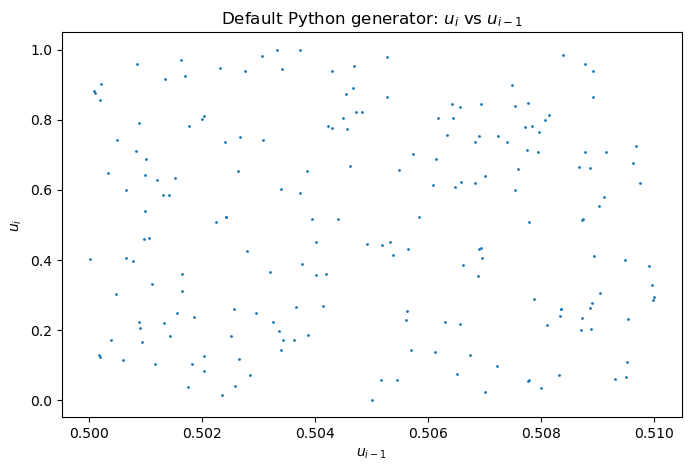

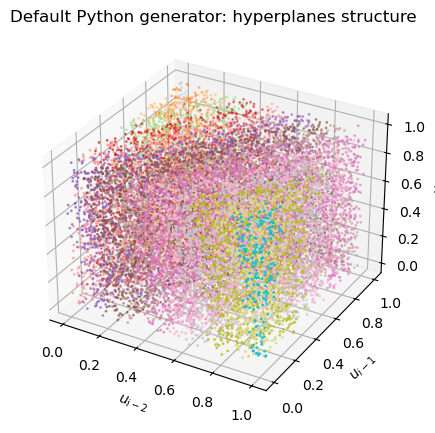

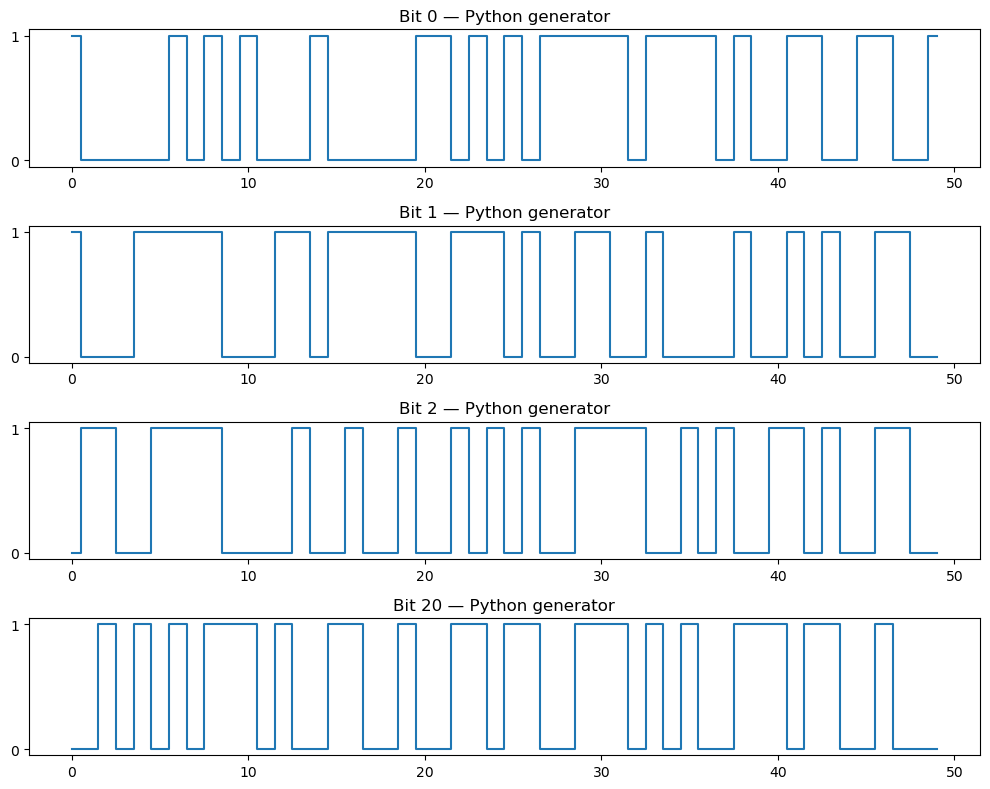

In [18]:
import random
u_py = [random.random() for _ in range(N)]

ui_prev = [u_py[i-1] for i in range(1, N) if 0.5 <= u_py[i-1] <= 0.51]
ui      = [u_py[i]   for i in range(1, N) if 0.5 <= u_py[i-1] <= 0.51]

plt.scatter(ui_prev, ui, s=1) # s = 1 to make the dots small
plt.xlabel(r'$u_{i-1}$')
plt.ylabel(r'$u_i$')
plt.title('Default Python generator: $u_i$ vs $u_{i-1}$')
plt.show()

ui2, ui1, ui = np.array(u_py[:-2]), np.array(u_py[1:-1]), np.array(u_py[2:])
k_vals = np.round(9*ui2 - 6*ui1 + ui).astype(int)  # which hyperplane: -5 to 9

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(ui2, ui1, ui, c=k_vals, cmap='tab20', s=1)
ax.set_xlabel(r'$u_{i-2}$')
ax.set_ylabel(r'$u_{i-1}$')
ax.set_zlabel(r'$u_i$')
ax.set_title('Default Python generator: hyperplanes structure')
plt.show()

L_py = [random.getrandbits(31) for _ in range(N)] # random integers using 31 random bits (same scale as RANDU)

fig, axes = plt.subplots(4, 1, figsize=(10, 8))
for k, ax in zip([0, 1, 2, 20], axes):
    bits = [(xi >> k) & 1 for xi in L_py[:50]]
    ax.plot(bits, drawstyle='steps-mid')
    ax.set_title(f'Bit {k} — Python generator')
    ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">2 &nbsp;·&nbsp; Laplace and Rejection</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  <p>Laplace density: &nbsp; <b>p(x) = ½ exp(−|x|)</b></p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 2.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Derive and implement a random generator for the <b>Laplace distribution</b>.
</div>

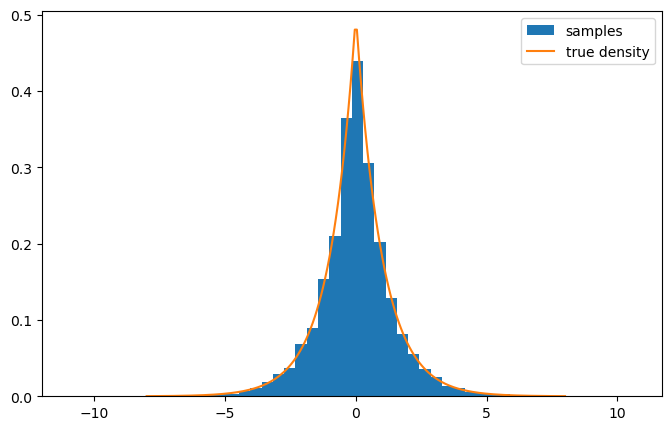

In [23]:
def laplace_generator(N):
    U = np.random.uniform(0, 1, N)
    X = np.where(U < 0.5, np.log(2*U), - np.log(2 * (1-U)))  # using the Inverse-CDF method 
    return X

samples = laplace_generator(10000)
x = np.linspace(-8, 8, 200)
plt.hist(samples, bins=50, density=True, label='samples')
plt.plot(x, 0.5 * np.exp(-np.abs(x)), label='true density')
plt.legend()
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 2.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Propose a <b>rejection sampler for N(0,1)</b> using the Laplace distribution as the proposal. Implement and test it.
</div>

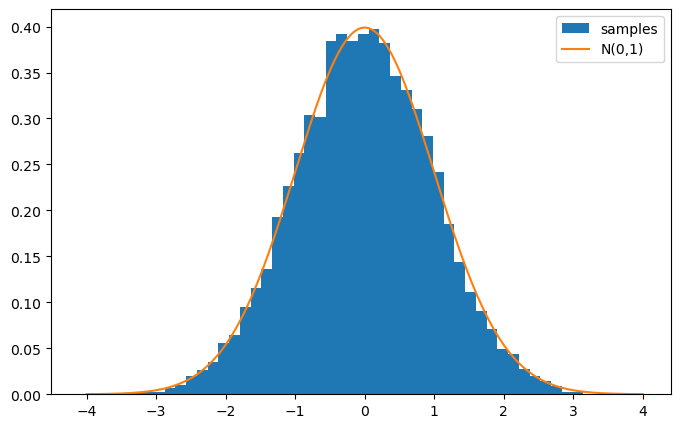

In [24]:
c = np.sqrt(2 * np.e / np.pi) # optimal constant to apply the rejection theorem

def rejection_normal(N):
    samples = []
    while len(samples) < N:
        X = laplace_generator(1)[0]
        U = np.random.uniform(0, 1)
        if U <= np.exp(np.abs(X) - X**2/2 - 0.5):
            samples.append(X)
    return np.array(samples)

# test
samples = rejection_normal(10000)
x = np.linspace(-4, 4, 200)
plt.hist(samples, bins=50, density=True, label='samples')
plt.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), label='N(0,1)')
plt.legend()
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 2.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Give the <b>acceptance rate</b>. Find a way to simplify the acceptance condition.
</div>

In [25]:
def rejection_normal_rate(N):
    accepted, total = 0, 0
    samples = []
    while len(samples) < N:
        X = laplace_generator(1)[0]
        U = np.random.uniform(0, 1)
        total += 1
        if U <= np.exp(np.abs(X) - X**2/2 - 0.5): # (*)
            samples.append(X)
            accepted += 1
    print(f"Empirical acceptance rate: {accepted/total:.3f}")
    # theoretically the acceptance rate is = to 1/c (since c tells us to what extent we overshoot the estimation)
    print(f"Theoretical: {np.sqrt(np.pi / (2*np.e)):.3f}") 
    return np.array(samples)

rejection_normal_rate(10000)

"""
The simplification has already been done in the line marked by (*) since have simplified the
expression of f(x)/(c * g(x)) as one single exponential!
"""

Empirical acceptance rate: 0.761
Theoretical: 0.760


array([-0.84102657, -0.23107531, -1.12712844, ..., -1.24216446,
        0.0532164 ,  0.25973703], shape=(10000,))

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 2.4</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Is it possible to <b>sample from the Laplace</b> distribution using a rejection sampler based on the normal distribution? Discuss.
</div>

As seen in the lecture, it is not possible to do it this way around.

Indeed, rejection sampling from Laplace using Normal as proposal requires finding a finite constant $c$ such that:

$$g(x) \leq c \cdot f(x) \quad \forall x$$

But since the Normal has lighter tails than the Laplace ($e^{-x^2/2}$ decays much faster than $e^{-|x|}$ as $|x| \to \infty$), the ratio $\frac{g(x)}{f(x)} \to \infty$ and no such finite $c$ exists. The rejection sampler would reject an unbounded proportion of proposals in the tails.

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">3 &nbsp;·&nbsp; Improved Box-Muller</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  <p>Algorithm: repeat U<sub>1</sub>, U<sub>2</sub> ~ U[−1,1] until U<sub>1</sub>² + U<sub>2</sub>² ≤ 1, then set S = U<sub>1</sub>² + U<sub>2</sub>² and return</p>
  <p style="text-align:center;"><b>X = U<sub>1</sub> √(−2 log S / S)</b> &nbsp;&nbsp; and &nbsp;&nbsp; <b>Y = U<sub>2</sub> √(−2 log S / S)</b></p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 3.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Show that the output of the algorithm has the desired distribution.
</div>

$(U_1, U_2)$ conditioned on $U_1^2 + U_2^2 \leq 1$ is uniform on the unit disk. Then let's rewrite in polar coordinates:

$$U_1 = R\cos\Theta, \quad U_2 = R\sin\Theta, \quad S = R^2$$

We also know that on the unit disk, $S \sim \mathcal{U}[0,1]$ and $\Theta \sim \mathcal{U}[0, 2\pi]$, independent.

Then:
$$X = U_1\sqrt{\frac{-2\log S}{S}} = R\cos\Theta \cdot \frac{\sqrt{-2\log S}}{R} = \cos\Theta\sqrt{-2\log S}$$
$$Y = U_2\sqrt{\frac{-2\log S}{S}} = \sin\Theta\sqrt{-2\log S}$$

Since $S \sim \mathcal{U}[0,1]$, we have $-2\log S \sim \chi^2(2)$, i.e. it is the squared radius of a 2D standard normal. Combined with $\Theta \sim \mathcal{U}[0,2\pi]$ independent, this is exactly the polar representation of two independent $\mathcal{N}(0,1)$ variables. $\blacksquare$

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 3.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
How can you <b>compare the performance</b> of this algorithm with the standard Box-Muller? Implement the comparison.
</div>

Acceptance rate: 0.789 (theoretical: 0.785)
Standard Box-Muller: 0.0026s
Improved Box-Muller:    0.0412s


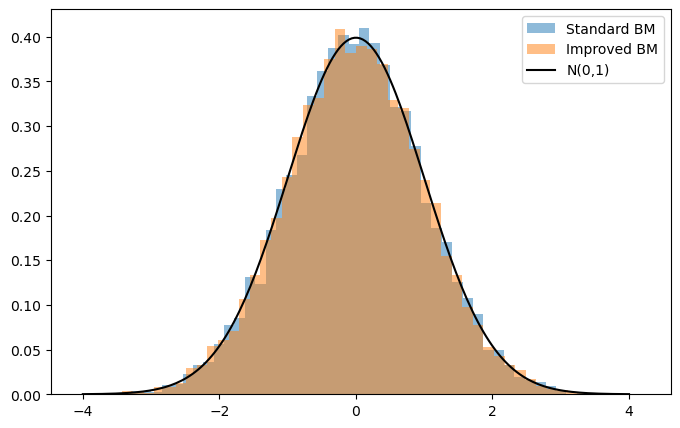

In [27]:
# the idea to compare the performance is to compute the time needed by both methods
import time

# Standard Box-Muller
def box_muller(N):
    U1 = np.random.uniform(0, 1, N//2)
    U2 = np.random.uniform(0, 1, N//2)
    X = np.sqrt(-2*np.log(U1)) * np.cos(2*np.pi*U2)
    Y = np.sqrt(-2*np.log(U1)) * np.sin(2*np.pi*U2)
    return np.concatenate([X, Y])

# Improved Box-Muller
def improved_box_muller(N):
    samples = []
    total, accepted = 0, 0
    while len(samples) < N:
        U1 = np.random.uniform(-1, 1)
        U2 = np.random.uniform(-1, 1)
        S = U1**2 + U2**2
        total += 1
        if S <= 1:
            accepted += 1
            factor = np.sqrt(-2*np.log(S)/S)
            samples.extend([U1*factor, U2*factor])
    print(f"Acceptance rate: {accepted/total:.3f} (theoretical: {np.pi/4:.3f})")
    return np.array(samples[:N])

N = 10000

# time taken to run them 
t0 = time.time(); bm = box_muller(N); t1 = time.time()
t2 = time.time(); polar = improved_box_muller(N); t3 = time.time()
print(f"Standard Box-Muller: {t1-t0:.4f}s")
print(f"Improved Box-Muller:    {t3-t2:.4f}s")

# little plotting to compare the quality of the samplers
x = np.linspace(-4, 4, 200)
plt.hist(bm, bins=50, density=True, alpha=0.5, label='Standard BM')
plt.hist(polar, bins=50, density=True, alpha=0.5, label='Improved BM')
plt.plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), 'k-', label='N(0,1)')
plt.legend()
plt.show()


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">4 &nbsp;·&nbsp; Geometric Distribution</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Propose <b>various algorithms</b> to sample from a geometric distribution. Implement them and discuss which one is best.
</div>

Direct:       0.327s
Inverse CDF:  0.009s
Exponential:  0.004s


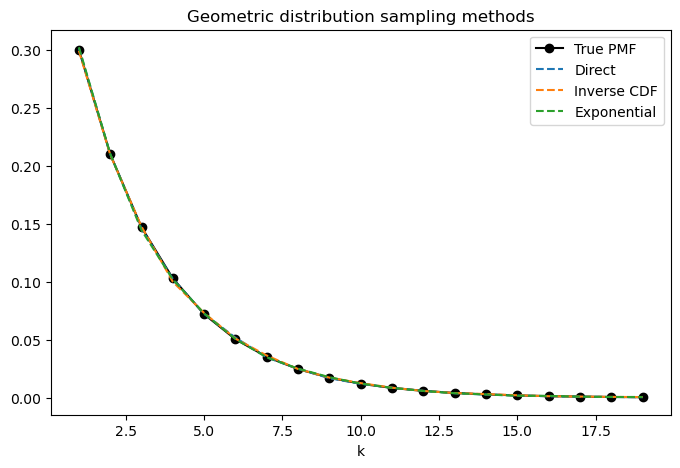

In [28]:
# as done in the previous question we will compare the different methods chosen below using the time taken
import time
p = 0.3   # geom param
N = 100000

# first method would be to compute it directly
def geom_direct(p, N):
    samples = []
    for _ in range(N):
        k = 1
        while np.random.uniform() > p:
            k += 1
        samples.append(k)
    return np.array(samples)

# the second one is the inverse-CDF method
def geom_inverse_cdf(p, N):
    U = np.random.uniform(0, 1, N)
    return np.ceil(np.log(U) / np.log(1-p)).astype(int)

# last one is the exponential
def geom_exponential(p, N):
    E = np.random.exponential(1 / (-np.log(1-p)), N)
    return np.floor(E).astype(int) + 1

# time comparisons 
t0 = time.time(); s1 = geom_direct(p, N);        print(f"Direct:       {time.time()-t0:.3f}s")
t0 = time.time(); s2 = geom_inverse_cdf(p, N);   print(f"Inverse CDF:  {time.time()-t0:.3f}s")
t0 = time.time(); s3 = geom_exponential(p, N);   print(f"Exponential:  {time.time()-t0:.3f}s")

# checking the distributions
k = np.arange(1, 20)
pmf = p * (1-p)**(k-1)
plt.plot(k, pmf, 'ko-', label='True PMF')
for s, label in [(s1,'Direct'), (s2,'Inverse CDF'), (s3,'Exponential')]:
    counts = np.bincount(s, minlength=20)[1:20] / N
    plt.plot(k, counts, '--', label=label)
plt.legend()
plt.xlabel('k')
plt.title('Geometric distribution sampling methods')
plt.show()

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">5 &nbsp;·&nbsp; Control Variates, Antithetic Variables, QMC</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  <p>X ~ N<sub>d</sub>(0, I<sub>d</sub>). We want to compute <b>P(X ∈ A)</b> where:</p>
  <p style="text-align:center;"><b>A = { (x<sub>1</sub>,…,x<sub>d</sub>) : |∏ x<sub>i</sub>| ≤ c }</b></p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 5.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Propose a <b>Monte Carlo algorithm</b> to approximate this probability. What issue occurs when c becomes small?
</div>

In [29]:
def mc_proba(d, c, N=100000):
    X = np.random.randn(N, d)  # N samples from N_d(0, I_d)
    prod = np.abs(np.prod(X, axis=1))    # abs for each sample
    indicator = (prod <= c).astype(float)
    estimate = indicator.mean()
    std = indicator.std() / np.sqrt(N)
    return estimate, std

# Test for different c values
d = 5
for c in [10, 1, 0.1, 0.01]:
    est, std = mc_proba(d, c)
    print(f"c={c:.2f}:  P(X∈A) ≈ {est:.4f}  ±  {std:.4f}")

"""
The issue when c becomes too small is that almost all indicators are 0.
So the event simulation becomes really rare which implies that both the variance
and relative error explode.
"""

c=10.00:  P(X∈A) ≈ 0.9986  ±  0.0001
c=1.00:  P(X∈A) ≈ 0.9225  ±  0.0008
c=0.10:  P(X∈A) ≈ 0.6008  ±  0.0015
c=0.01:  P(X∈A) ≈ 0.2545  ±  0.0014


'\nThe issue when c becomes too small is that almost all indicators are 0.\nSo the event simulation becomes really rare which implies that both the variance\nand relative error explode.\n'

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 5.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Use <b>control variates</b> to improve the results.
</div>

In [30]:
def mc_control_variate(d, c, N=100000):
    X = np.random.randn(N, d)
    prod = np.abs(np.prod(X, axis=1))
    indicator = (prod <= c).astype(float)

    # control variaten defined as follows
    Z = prod
    mu_Z = (np.sqrt(2/np.pi))**d  # known expectation

    # optimal beta
    beta = np.cov(indicator, Z)[0,1] / np.var(Z)

    # corrected estimator
    cv_samples = indicator - beta * (Z - mu_Z)
    estimate = cv_samples.mean()
    std = cv_samples.std() / np.sqrt(N)
    return estimate, std

# compare with plain MC
d = 5
for c in [10, 1, 0.1, 0.01]:
    est_mc,  std_mc  = mc_proba(d, c)
    est_cv,  std_cv  = mc_control_variate(d, c)
    print(f"c={c:.2f}:  MC={est_mc:.4f}±{std_mc:.4f}  |  CV={est_cv:.4f}±{std_cv:.4f}")



c=10.00:  MC=0.9984±0.0001  |  CV=0.9986±0.0001
c=1.00:  MC=0.9215±0.0009  |  CV=0.9234±0.0006
c=0.10:  MC=0.6017±0.0015  |  CV=0.5995±0.0014
c=0.01:  MC=0.2550±0.0014  |  CV=0.2551±0.0014


<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 5.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Can you use <b>antithetic variables</b> in this setting? Discuss.
</div>

In [ ]:
"""
Since both X and the indicator are symmetric around 0 we have f(X) = f(-X).
Hence, it's possible to use antithetic variables. However, we should notice that since the indicator
and its opposite are identical, the antithetic estimator gives zero variance reduction.
"""
def mc_antithetic(d, c, N=100000):
    X = np.random.randn(N//2, d)
    prod_pos = np.abs(np.prod(X, axis=1))
    prod_neg = np.abs(np.prod(-X, axis=1))   # same as prod_pos since absolute value!
    
    ind_pos = (prod_pos <= c).astype(float)
    ind_neg = (prod_neg <= c).astype(float)
    
    av_samples = (ind_pos + ind_neg) / 2
    estimate = av_samples.mean()
    std = av_samples.std() / np.sqrt(N//2)
    return estimate, std

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 5.4</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Apply <b>QMC (Quasi-Monte Carlo)</b>. Perform experiments to assess the performance gain.
</div>

c                MC           CV          QMC
10     0.9987±0.0001 0.9987±0.0001 0.9987±0.0001
1      0.9211±0.0009 0.9212±0.0006 0.9224±0.0008
0.1    0.6019±0.0015 0.6015±0.0014 0.6009±0.0015
0.01   0.2542±0.0014 0.2544±0.0013 0.2550±0.0014


/var/folders/zd/9n4hmj417rb5xl6pg1v06wsc0000gn/T/ipykernel_84374/1295561374.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(N)               # points in [0,1]^d, very evenly spread


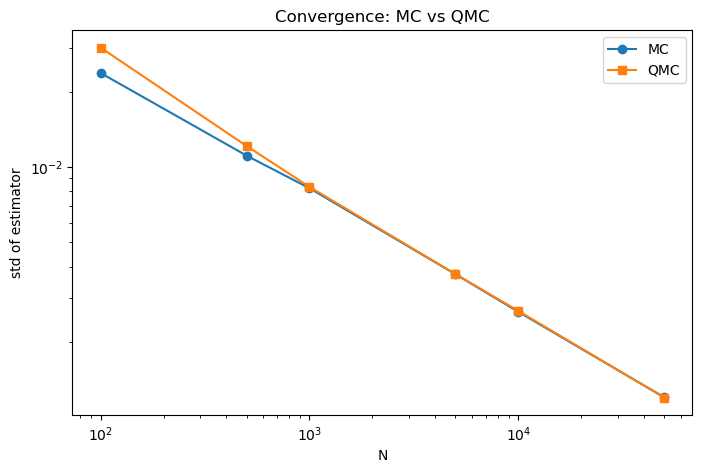

In [32]:
from scipy.stats import qmc, norm

def mc_qmc(d, c, N=100000):
    # QMC: using the Sobol sequence here
    sampler = qmc.Sobol(d=d, scramble=True)
    U = sampler.random(N)               # points in [0,1]^d, very evenly spread
    X = norm.ppf(U)                     # transform to N_d(0, I_d)
    prod = np.abs(np.prod(X, axis=1))
    indicator = (prod <= c).astype(float)
    estimate = indicator.mean()
    std = indicator.std() / np.sqrt(N)
    return estimate, std

# compare all methods
d = 5
print(f"{'c':<6} {'MC':>12} {'CV':>12} {'QMC':>12}")
for c in [10, 1, 0.1, 0.01]:
    est_mc,  std_mc  = mc_proba(d, c)
    est_cv,  std_cv  = mc_control_variate(d, c)
    est_qmc, std_qmc = mc_qmc(d, c)
    print(f"{c:<6} {est_mc:.4f}±{std_mc:.4f} {est_cv:.4f}±{std_cv:.4f} {est_qmc:.4f}±{std_qmc:.4f}")

# convergence comparison: std vs N
Ns = [100, 500, 1000, 5000, 10000, 50000]
std_mc_list, std_qmc_list = [], []
for n in Ns:
    _, s_mc  = mc_proba(d=5, c=1, N=n)
    _, s_qmc = mc_qmc(d=5, c=1, N=n)
    std_mc_list.append(s_mc)
    std_qmc_list.append(s_qmc)

plt.loglog(Ns, std_mc_list,  'o-', label='MC')
plt.loglog(Ns, std_qmc_list, 's-', label='QMC')
plt.xlabel('N')
plt.ylabel('std of estimator')
plt.title('Convergence: MC vs QMC')
plt.legend()
plt.show()

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">6 &nbsp;·&nbsp; Importance Sampling</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Approximate expectations w.r.t. X | X ∈ A where X ~ N<sub>d</sub>(0, I<sub>d</sub>). The conditional density is:
  <p style="text-align:center;"><b>f(x) = (2π)<sup>−d/2</sup> / P(X ∈ A) · exp(−½ Σ x<sub>i</sub>²)</b></p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 6.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
A friend proposes: (a) sample X<sub>i</sub> from N<sub>d</sub>(0,I); (b) compute empirical mean and covariance of points in A; (c) use a Gaussian proposal with those moments. Is this a good idea? Discuss and/or implement.
</div>

The friend's idea is intuitive but not valid as stated. Indeed, the proposal $\mathcal{N}(\hat{\mu}, \hat{\Sigma})$ is centered near where $X|X\in A$ actually lives, with roughly the right covariance structure. It makes this a better starting point than $\mathcal{N}_d(0,I)$. However the main problem comes from the fact that the proposal is built from the same samples used to compute the IS estimate, creating a circular dependency that invalidates standard IS theory. The weights $\frac{f(X_i)}{q(X_i)}$ are no longer independent of the samples. Moreover, and for small $c$, almost no initial samples land in $A$, so $\hat{\mu}$ and $\hat{\Sigma}$ are estimated from very few points -making it completely unreliable. Finally, we could notice a Gaussian proposal may not cover the tails of $X|X\in A$ properly, causing importance weights to explode.

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 6.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Try to adapt the solution to get a <b>valid answer</b>.
</div>

In [33]:
from scipy.stats import multivariate_normal

def adaptive_IS(d, c, N1=100000, N2=100000):
    # build proposal from first batch
    X1 = np.random.randn(N1, d)
    in_A = np.abs(np.prod(X1, axis=1)) <= c
    X_A = X1[in_A]
    
    if len(X_A) < 2:
        print("Too few samples in A to estimate proposal")
        return None
    
    mu_hat = X_A.mean(axis=0)
    Sigma_hat = np.cov(X_A.T)
    
    # fresh samples from proposal q in order to compute the estimate independently
    X2 = multivariate_normal.rvs(mean=mu_hat, cov=Sigma_hat, size=N2)
    
    # importance weights f(x)/q(x)
    log_f = -0.5 * np.sum(X2**2, axis=1)           # log of N_d(0,I) up to constant
    log_q = multivariate_normal.logpdf(X2, mean=mu_hat, cov=Sigma_hat)
    log_w = log_f - log_q
    w = np.exp(log_w - log_w.max())                # normalize for numerical stability
    
    # self-normalized IS estimate of P(X in A)
    in_A2 = np.abs(np.prod(X2, axis=1)) <= c
    estimate = np.sum(w * in_A2) / np.sum(w)
    return estimate

for c in [1, 0.1, 0.01]:
    est = adaptive_IS(d=5, c=c)
    print(f"c={c}: P(X∈A) ≈ {est:.4f}")

c=1: P(X∈A) ≈ 0.9224
c=0.1: P(X∈A) ≈ 0.5993
c=0.01: P(X∈A) ≈ 0.2473


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">7 &nbsp;·&nbsp; Metropolis-Hastings</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Bivariate target distribution:
  <p style="text-align:center;"><b>p(x<sub>1</sub>, x<sub>2</sub>) = 1/(2π√(1−ρ²)) · exp{ −1/(2(1−ρ²)) · (x<sub>1</sub>² + x<sub>2</sub>² − 2ρx<sub>1</sub>x<sub>2</sub>) }</b></p>
  with ρ ∈ [−1, 1].
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 7.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Which distribution do you recognize?
</div>

I recognize a bivariate Gaussian distribution $\mathcal{N}_2(\mathbf{0}, \Sigma)$ with zero mean and covariance matrix:

$$\Sigma = \begin{pmatrix} 1 & \rho \ \rho & 1 \end{pmatrix}$$

Indeed, the exponent $-\frac{1}{2(1-\rho^2)}(x_1^2 + x_2^2 - 2\rho x_1 x_2)$ is exactly $-\frac{1}{2}\mathbf{x}^T\Sigma^{-1}\mathbf{x}$, since:

$$\Sigma^{-1} = \frac{1}{1-\rho^2}\begin{pmatrix} 1 & -\rho \ -\rho & 1 \end{pmatrix}$$

and the normalizing constant $\frac{1}{2\pi\sqrt{1-\rho^2}}$ matches $\frac{1}{2\pi|\Sigma|^{1/2}}$ since $|\Sigma| = 1-\rho^2$.

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 7.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Derive the <b>conditional distributions</b> of each component. Implement the <b>Gibbs sampler</b>, plot density contours and the chain trajectory. What happens when ρ → 1?
</div>

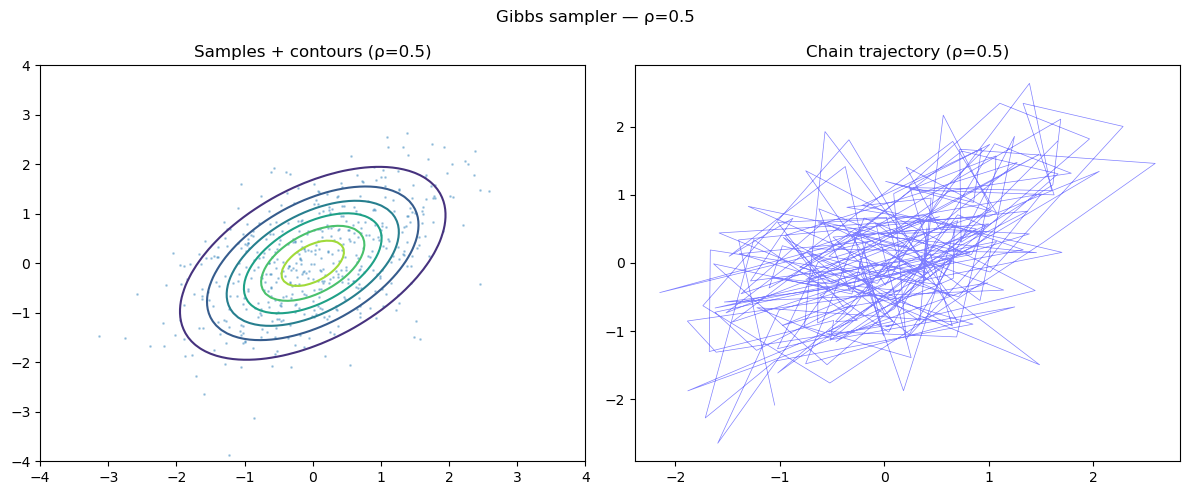

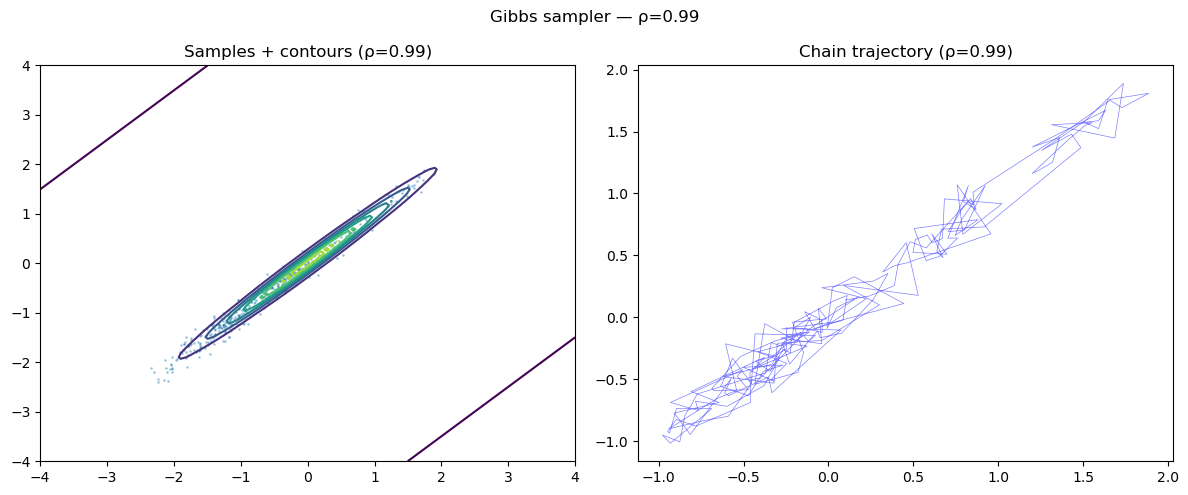

In [35]:
# The conditional distributions are the following: 
# $$x_1 | x_2 \sim \mathcal{N}(\rho x_2,\ 1-\rho^2)$$
# $$x_2 | x_1 \sim \mathcal{N}(\rho x_1,\ 1-\rho^2)$$

def gibbs_sampler(rho, N=10000):
    samples = np.zeros((N, 2))
    x1, x2 = 0.0, 0.0
    for i in range(N):
        x1 = np.random.normal(rho * x2, np.sqrt(1 - rho**2))
        x2 = np.random.normal(rho * x1, np.sqrt(1 - rho**2))
        samples[i] = [x1, x2]
    return samples

# Plot for rho = 0.5 and rho = 0.99
for rho in [0.5, 0.99]:
    samples = gibbs_sampler(rho, N=10000)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # density contours
    x = np.linspace(-4, 4, 100)
    X1, X2 = np.meshgrid(x, x)
    Z = np.exp(-1/(2*(1-rho**2)) * (X1**2 + X2**2 - 2*rho*X1*X2))
    axes[0].contour(X1, X2, Z, levels=8)
    axes[0].scatter(samples[:500,0], samples[:500,1], s=1, alpha=0.3)
    axes[0].set_title(f'Samples + contours (ρ={rho})')
    
    # chain trajectory
    axes[1].plot(samples[:200, 0], samples[:200, 1], 'b-', alpha=0.5, linewidth=0.5)
    axes[1].set_title(f'Chain trajectory (ρ={rho})')
    
    plt.suptitle(f'Gibbs sampler — ρ={rho}')
    plt.tight_layout()
    plt.show()

# When $\rho \to 1$ the chain mixes very poorly. Indeed, the conditional variance $1-\rho^2 \to
# 0$ so each step barely moves, and the chain gets stuck exploring a narrow diagonal band 
# for a long time before covering the full distribution.

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 7.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Implement a <b>RWHM (Random Walk Hastings-Metropolis)</b> with Gaussian proposal of variance σ = τI<sub>2</sub>. Explore different values of τ, especially when ρ is close to 1. Then try σ proportional to the variance of the target.
</div>

τ=0.1, ρ=0.5: acceptance rate = 0.945
τ=1.0, ρ=0.5: acceptance rate = 0.518
τ=5.0, ρ=0.5: acceptance rate = 0.056


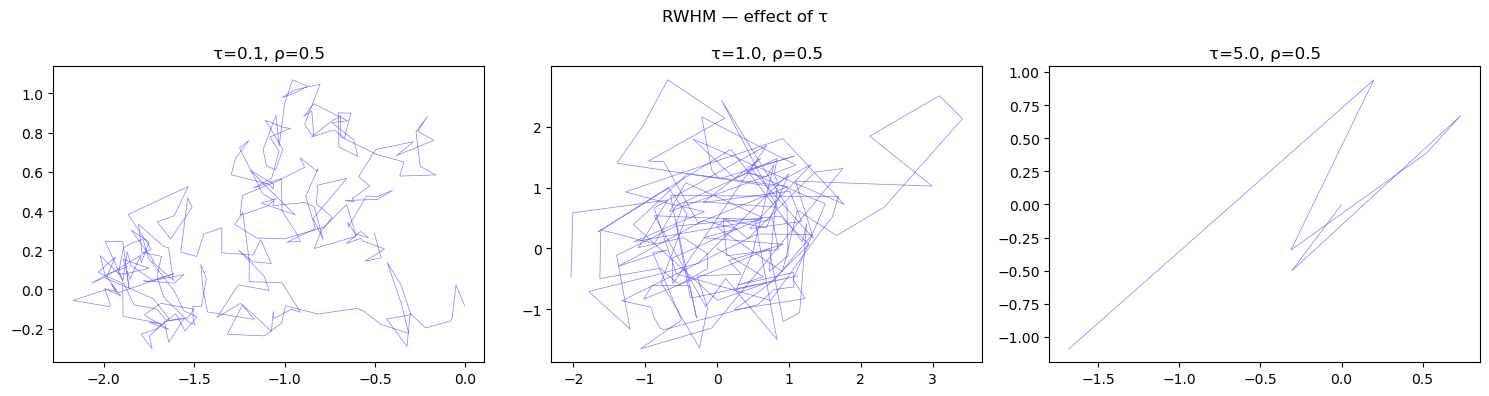

τ=0.1, ρ=0.99: acceptance rate = 0.704
τ=1.0, ρ=0.99: acceptance rate = 0.108
τ=5.0, ρ=0.99: acceptance rate = 0.010


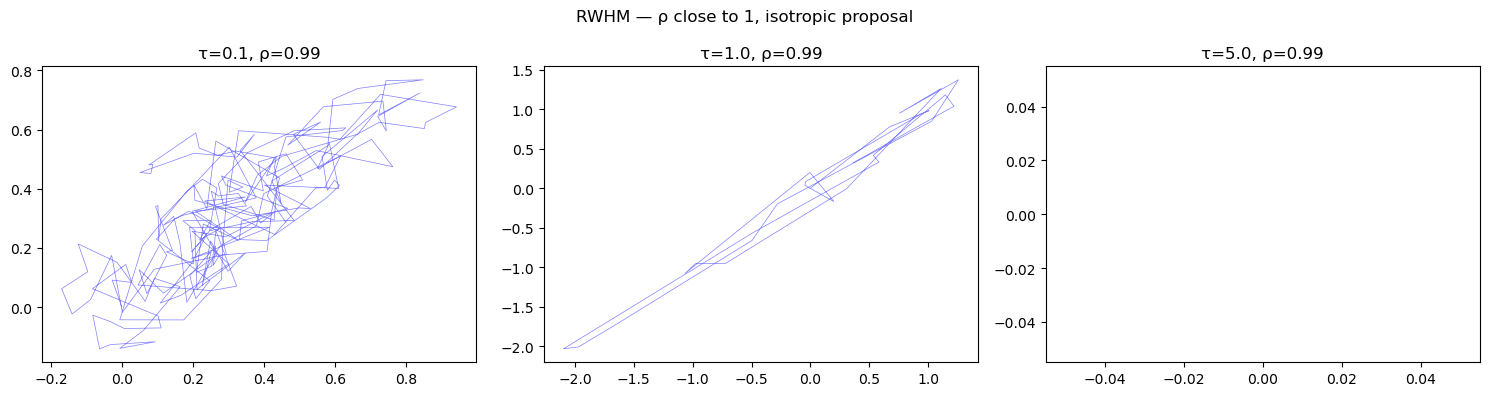

τ=0.1, ρ=0.99: acceptance rate = 0.948
τ=1.0, ρ=0.99: acceptance rate = 0.554
τ=2.0, ρ=0.99: acceptance rate = 0.295


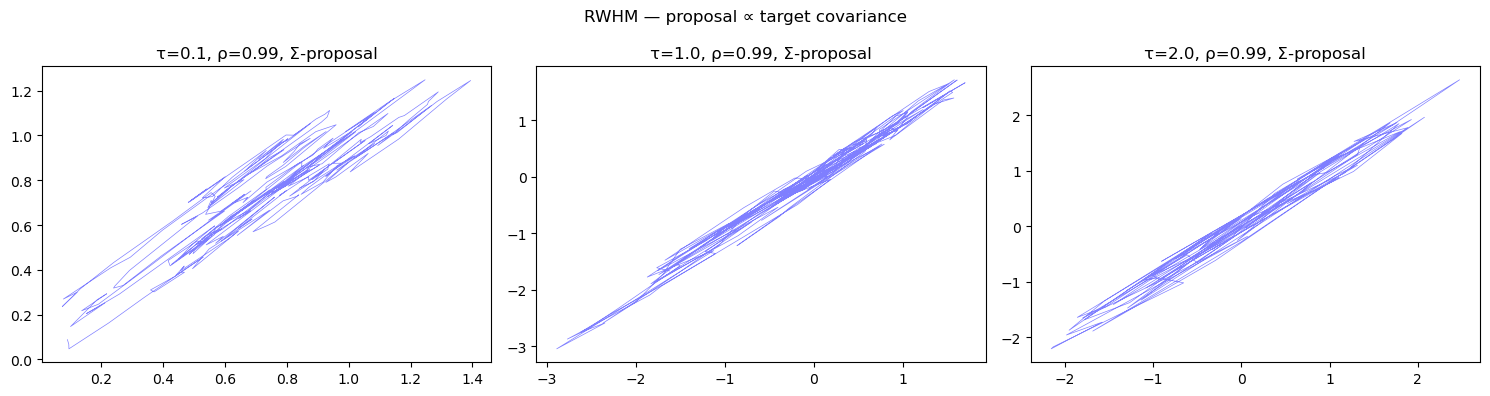

In [36]:
def log_target(x, rho):
    # log of target density (up to constant)
    return -1/(2*(1-rho**2)) * (x[0]**2 + x[1]**2 - 2*rho*x[0]*x[1])

def rwhm(rho, tau, N=10000, cov=None):
    samples = np.zeros((N, 2))
    x = np.array([0.0, 0.0])
    accepted = 0
    
    for i in range(N):
        # propose x' = x + noise
        if cov is None:
            noise = np.random.multivariate_normal([0,0], tau**2 * np.eye(2))
        else:
            noise = np.random.multivariate_normal([0,0], tau**2 * cov)
        x_prop = x + noise
        
        # acceptance ratio (log scale)
        log_alpha = log_target(x_prop, rho) - log_target(x, rho)
        if np.log(np.random.uniform()) < log_alpha:
            x = x_prop
            accepted += 1
        samples[i] = x
    
    print(f"τ={tau}, ρ={rho}: acceptance rate = {accepted/N:.3f}")
    return samples

# effect of tau for rho=0.5
rho = 0.5
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tau in zip(axes, [0.1, 1.0, 5.0]):
    samples = rwhm(rho, tau)
    ax.plot(samples[:300, 0], samples[:300, 1], 'b-', alpha=0.5, linewidth=0.5)
    ax.set_title(f'τ={tau}, ρ={rho}')
plt.suptitle('RWHM — effect of τ')
plt.tight_layout()
plt.show()

# effect of rho close to 1, isotropic proposal
rho = 0.99
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tau in zip(axes, [0.1, 1.0, 5.0]):
    samples = rwhm(rho, tau)
    ax.plot(samples[:300, 0], samples[:300, 1], 'b-', alpha=0.5, linewidth=0.5)
    ax.set_title(f'τ={tau}, ρ={rho}')
plt.suptitle('RWHM — ρ close to 1, isotropic proposal')
plt.tight_layout()
plt.show()

# proposal proportional to target covariance
Sigma = np.array([[1, rho], [rho, 1]])  # target covariance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tau in zip(axes, [0.1, 1.0, 2.0]):
    samples = rwhm(rho, tau, cov=Sigma)
    ax.plot(samples[:300, 0], samples[:300, 1], 'b-', alpha=0.5, linewidth=0.5)
    ax.set_title(f'τ={tau}, ρ={rho}, Σ-proposal')
plt.suptitle('RWHM — proposal ∝ target covariance')
plt.tight_layout()
plt.show()

# we notice that: 
# for mall τ, there is a high acceptance rate but tiny steps = slow mixing
# for large τ: most proposals rejected which implies that the chain barely moves
# for ρ close to 1, isotropic proposal: all values of τ struggle because the target is
# very elongated along the diagonal but the proposal is a circle
# last proposal ∝ Σ: it aligns the proposal with the target's elongation which is 
# much better mixing even for ρ=0.99

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">8 &nbsp;·&nbsp; Ising</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Distribution over x = (x<sub>1</sub>,…,x<sub>n</sub>) ∈ {0,1}<sup>n</sup> on a k×k grid:
  <p style="text-align:center;"><b>p(x) ∝ exp{ α Σ x<sub>i</sub> + β Σ<sub>i~j</sub> 1{x<sub>i</sub> = x<sub>j</sub>} }</b></p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 8.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Derive the <b>full conditional distribution</b> of x<sub>i</sub>. Derive and implement the <b>Gibbs sampler</b>.
</div>

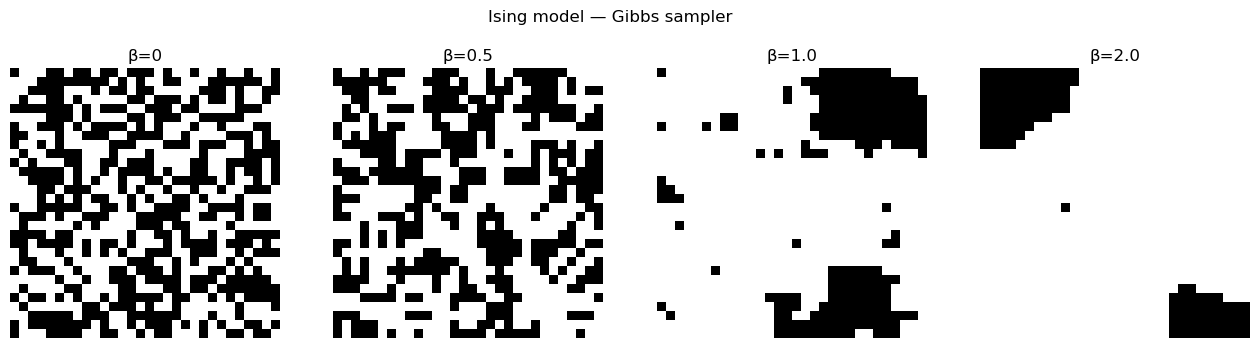

In [84]:
# First let's derive the full conditional. Since $x_i \in {0,1}$, $x_i | x_{-i}$ is a Bernoulli. 
# Let $n_1$ = number of neighbors of $i$ equal to 1, $n_0$ = number equal to 0. Then:
# $$\log \frac{P(x_i=1|x_{-i})}{P(x_i=0|x_{-i})} = \alpha + \beta(n_1 - n_0)$$. So 
# $x_i | x_{-i} \sim \text{Bernoulli}(\sigma(\alpha + \beta(n_1 - n_0)))$ where $\sigma$ is the sigmoid.

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def gibbs_ising(k, alpha, beta, N=1000):
    x = np.random.randint(0, 2, (k, k)).astype(float)
    samples = []

    for _ in range(N):
        for i in range(k):
            for j in range(k):
                # neighbors (with boundary conditions)
                neighbors = []
                if i > 0:   neighbors.append(x[i-1, j])
                if i < k-1: neighbors.append(x[i+1, j])
                if j > 0:   neighbors.append(x[i, j-1])
                if j < k-1: neighbors.append(x[i, j+1])
                
                n1 = sum(neighbors)
                n0 = len(neighbors) - n1
                p = sigmoid(alpha + beta * (n1 - n0))
                x[i, j] = np.random.binomial(1, p)
        samples.append(x.copy())
    
    return np.array(samples)

# Visualize final state for different beta
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, beta in zip(axes, [0, 0.5, 1.0, 2.0]):
    samples = gibbs_ising(k=30, alpha=0, beta=beta, N=200)
    ax.imshow(samples[-1], cmap='gray')
    ax.set_title(f'β={beta}')
    ax.axis('off')
plt.suptitle('Ising model — Gibbs sampler')
plt.savefig('img/ising_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# as beta increases we notice that it goes from random noise to large coherent clusters

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 8.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Suggest a method to <b>visualise mixing</b>. Compare for different β > 0.
</div>

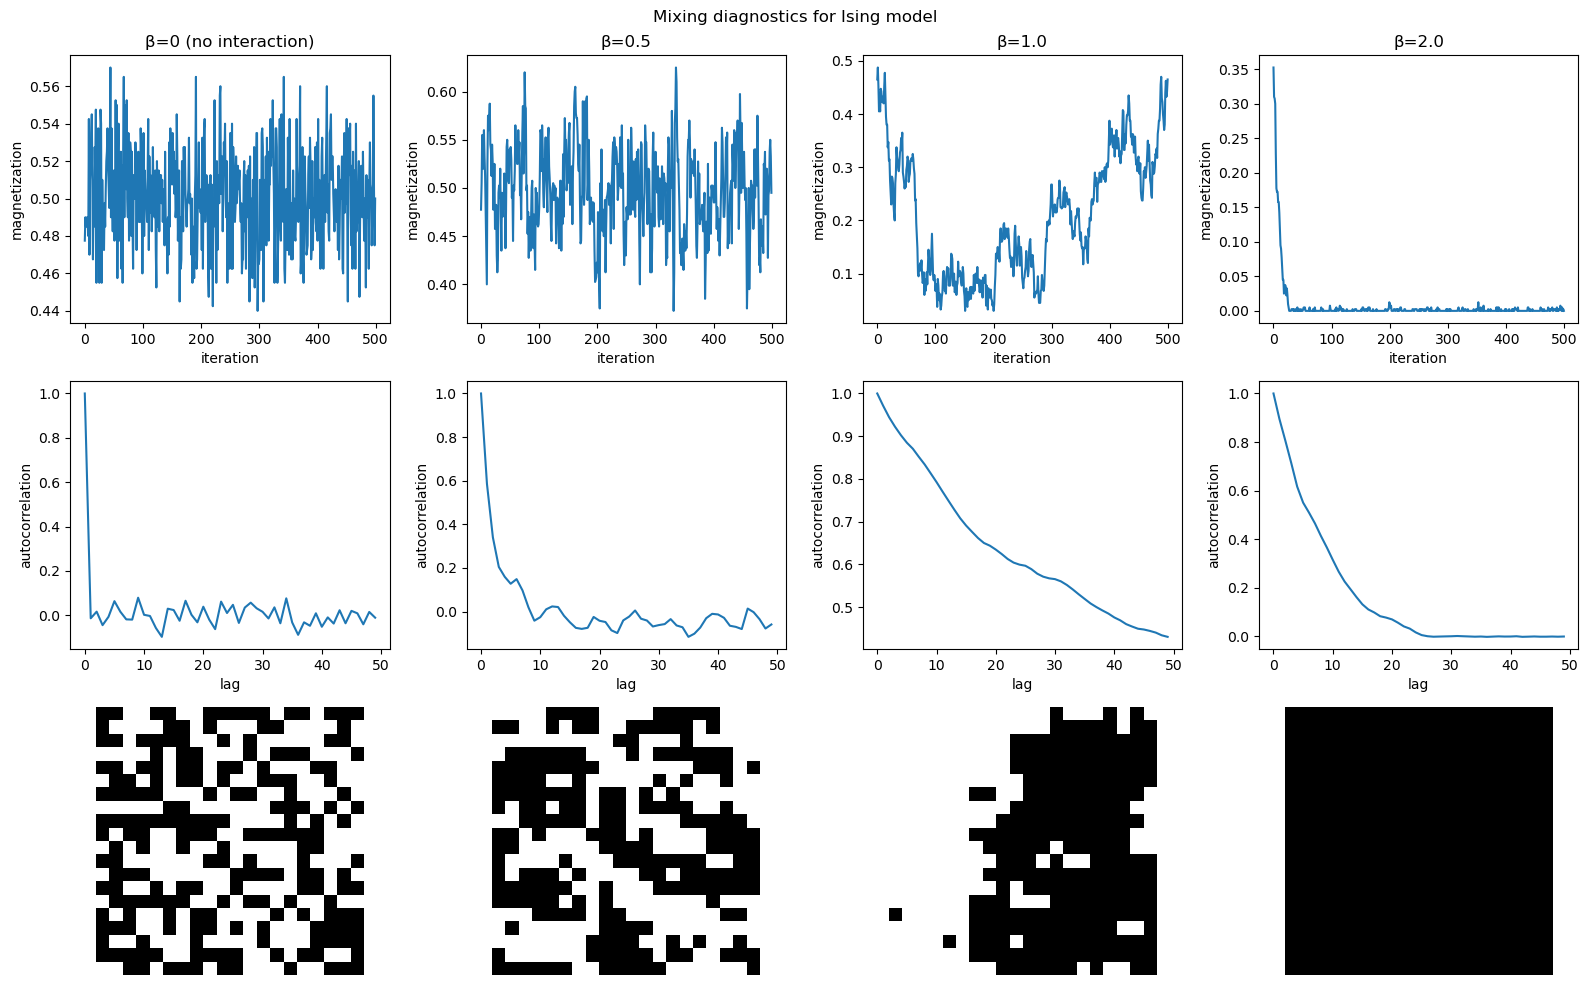

In [ ]:
# Some methods to visualize mixing are: 

# Magnetization over time: plot average value of the grid) across iterations. It gives a good mixing 
# when it fluctuates rapidly around a stable mean and a poor one when stuck near 0 or 1 for long periods.

# Autocorrelation: plot the autocorrelation of the magnetization sequence. Again there is a good mixing 
# when it drops to 0 quickly whereas a slow decay indicates a poor mixing.

# Finally, grid snapshots: show the grid at different iterations. A good mixing corresponds to pattern 
# changes significantly between snapshots compared to nearly identical snapshots (poor mixing).


fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for col, beta in enumerate([0, 0.5, 1.0, 2.0]):
    samples = gibbs_ising(k=20, alpha=0, beta=beta, N=500)
    magnetization = samples.mean(axis=(1,2))
    
    # magnetization over time
    axes[0, col].plot(magnetization)
    axes[0, col].set_title(f'β={beta}')
    axes[0, col].set_xlabel('iteration')
    axes[0, col].set_ylabel('magnetization')
    
    # autocorrelation
    mag_centered = magnetization - magnetization.mean()
    acf = np.correlate(mag_centered, mag_centered, mode='full')
    acf = acf[len(acf)//2:] / acf[len(acf)//2]  # normalize
    axes[1, col].plot(acf[:50])
    axes[1, col].set_xlabel('lag')
    axes[1, col].set_ylabel('autocorrelation')
    
    # final grid snapshot
    axes[2, col].imshow(samples[-1], cmap='gray')
    axes[2, col].axis('off')

axes[0,0].set_title('β=0 (no interaction)')
plt.suptitle('Mixing diagnostics for Ising model')
plt.tight_layout()
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 8.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Find the <b>critical value β<sub>0</sub></b> beyond which mixing becomes very poor. Give intuition for what happens when β > β<sub>0</sub>.
</div>

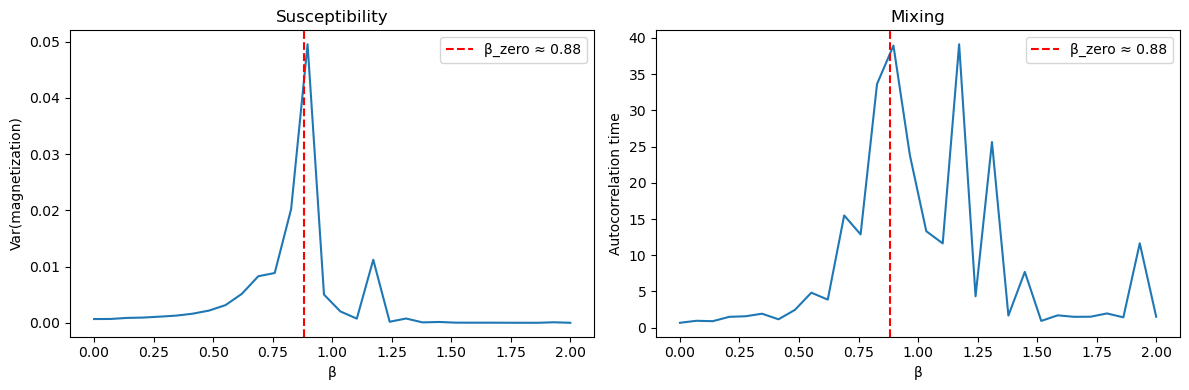

Theoretical β_zero = ln(1+√2) ≈ 0.8814
Empirical peak at β ≈ 0.8966


In [43]:
betas = np.linspace(0, 2, 30)
variances = []
autocorr_times = []
burn_in = 200  # discard first 200 iterations

for beta in betas:
    samples = gibbs_ising(k=20, alpha=0, beta=beta, N=700 + burn_in)
    samples = samples[burn_in:]  # discard burn-in
    mag = samples.mean(axis=(1,2))
    
    variances.append(mag.var())
    
    mag_c = mag - mag.mean()
    acf = np.correlate(mag_c, mag_c, mode='full')
    acf = acf[len(acf)//2:] / acf[len(acf)//2]
    autocorr_times.append(acf[:50].sum())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(betas, variances)
axes[0].axvline(np.log(1+np.sqrt(2)), color='r', linestyle='--', label=f'β_zero ≈ {np.log(1+np.sqrt(2)):.2f}')
axes[0].set_xlabel('β')
axes[0].set_ylabel('Var(magnetization)')
axes[0].set_title('Susceptibility')
axes[0].legend()

axes[1].plot(betas, autocorr_times)
axes[1].axvline(np.log(1+np.sqrt(2)), color='r', linestyle='--', label=f'β_zero ≈ {np.log(1+np.sqrt(2)):.2f}')
axes[1].set_xlabel('β')
axes[1].set_ylabel('Autocorrelation time')
axes[1].set_title('Mixing')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical β_zero = ln(1+√2) ≈ {np.log(1+np.sqrt(2)):.4f}")
print(f"Empirical peak at β ≈ {betas[np.argmax(variances)]:.4f}")

# Empirically by plotting the variance of magnetization, we know that it peaks sharply at the critical point. This is 
# called the magnetic susceptibility). Here we get beta = 0.8966 which is close to the theoretical one.


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">9 &nbsp;·&nbsp; Hierarchical Bayesian Modelling</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  <p>Model: &nbsp; y<sub>i</sub>|θ<sub>i</sub> ~ Bin(n<sub>i</sub>, θ<sub>i</sub>), &nbsp; θ<sub>i</sub> ~ Beta(α, β), &nbsp; α, β ~ Gamma(a, b)</p>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 9.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Derive the <b>posterior density</b> of all unknown variables and their <b>full conditional distributions</b>.
</div>

Posterior density:

$$p(\theta, \alpha, \beta \mid y) \propto \prod_{i=1}^k \theta_i^{y_i+\alpha-1}(1-\theta_i)^{n_i-y_i+\beta-1} \cdot \frac{p(\alpha),p(\beta)}{B(\alpha,\beta)^k}$$

Full conditional for $\theta_i$ (conjugate Beta-Binomial):
$$\theta_i \mid \text{rest} \sim \text{Beta}(y_i + \alpha,\ n_i - y_i + \beta)$$

Full conditional for $\alpha$ (non-standard distribution):
$$p(\alpha \mid \text{rest}) \propto \frac{\left(\prod_i \theta_i\right)^{\alpha-1}}{B(\alpha,\beta)^k} \cdot p(\alpha)$$

Full conditional for $\beta$ (non-standard distribution):
$$p(\beta \mid \text{rest}) \propto \frac{\left(\prod_i (1-\theta_i)\right)^{\beta-1}}{B(\alpha,\beta)^k} \cdot p(\beta)$$

Since the conditionals for $\alpha$ and $\beta$ are not standard distributions, we use a Metropolis-Hastings within Gibbs step for these two parameters. Hence, we propose $\alpha' = \alpha + \epsilon$ with $\epsilon \sim \mathcal{N}(0, \sigma^2)$, and accept with probability:

$$\min\left(1,\ \frac{p(\alpha'|\text{rest})}{p(\alpha|\text{rest})}\right) = \min\left(1,\ \left(\prod_i\theta_i\right)^{\alpha'-\alpha} \cdot \frac{B(\alpha,\beta)^k}{B(\alpha',\beta)^k} \cdot \frac{p(\alpha')}{p(\alpha)}\right)$$

Same logic goes for $\beta$.

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 9.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Simulate data (α=1, β=10). Implement the <b>Gibbs sampler</b> and assess its performance.
</div>

Simulated data:
n: [48 38 24 ... 42 45 12]
y: [5 2 4 ... 8 6 1]
θ_true: [0.081 0.084 0.097 ... 0.337 0.117 0.138]


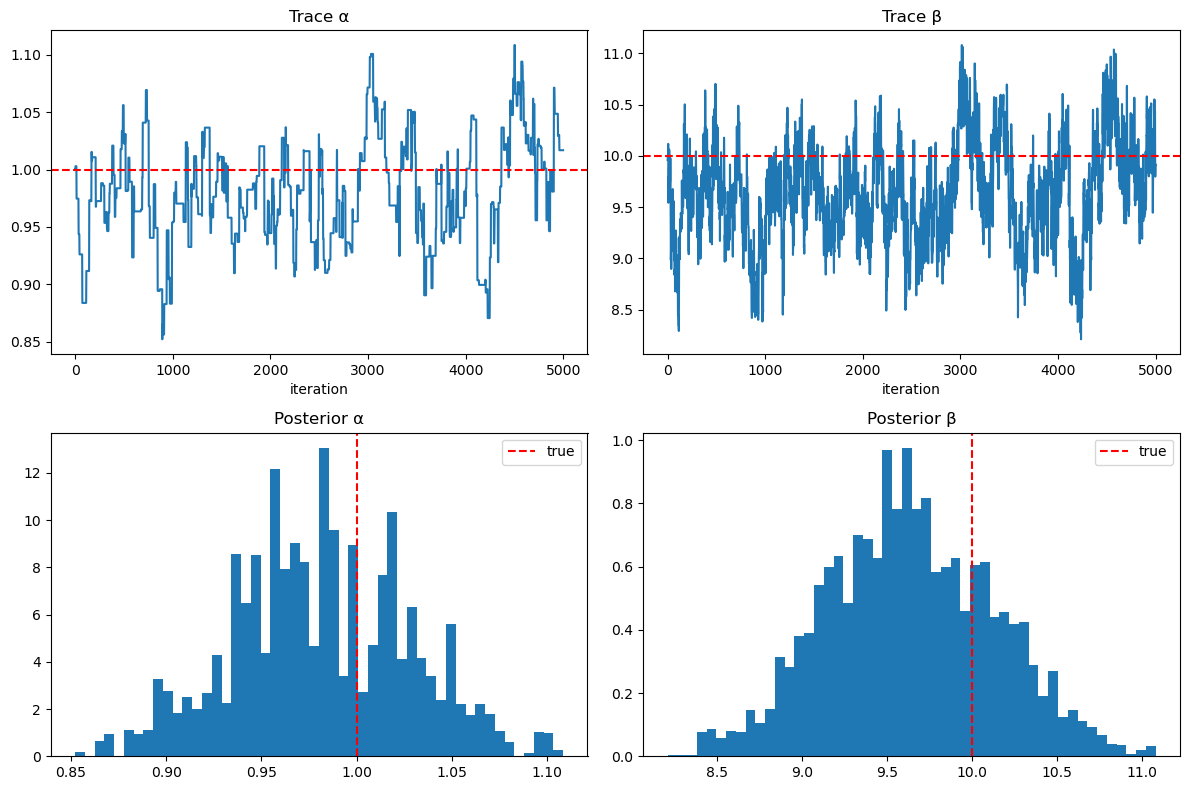

α: true=1.0, posterior mean=0.981
β: true=10.0, posterior mean=9.637


In [48]:
from scipy.special import betaln  # log of Beta function

# true parameters
alpha_true, beta_true = 1.0, 10.0
k = 2000  # number of groups
np.random.seed(42)

# simulate n_i and theta_i, then y_i
n = np.random.randint(10, 50, size=k)        # group sizes
theta_true = np.random.beta(alpha_true, beta_true, size=k)  # true probabilities
y = np.random.binomial(n, theta_true)         # observations

print("Simulated data:")
print(f"n: {n}")
print(f"y: {y}")
print(f"θ_true: {theta_true.round(3)}")

# hyperpriors: alpha, beta ~ Gamma(a,b) with a=b=1
a, b = 1.0, 1.0

# gives the log of full conditional 
def log_cond_alpha(alpha, beta, theta, a, b):
    if alpha <= 0: return -np.inf
    return (alpha-1)*np.sum(np.log(theta)) - len(theta)*betaln(alpha,beta) + (a-1)*np.log(alpha) - b*alpha

# same for beta
def log_cond_beta(alpha, beta, theta, a, b):
    if beta <= 0: return -np.inf
    return (beta-1)*np.sum(np.log(1-theta)) - len(theta)*betaln(alpha,beta) + (a-1)*np.log(beta) - b*beta

def gibbs_hierarchical(y, n, N=5000, sigma_mh=0.3):
    k = len(y)
    
    # initialize
    alpha, beta = 1.0, 10.0
    theta = np.random.beta(1, 1, size=k)
    
    samples_theta = np.zeros((N, k))
    samples_alpha = np.zeros(N)
    samples_beta  = np.zeros(N)
    
    for t in range(N):
        # sample theta_i | rest ~ Beta(y_i+alpha, n_i-y_i+beta)
        theta = np.random.beta(y + alpha, n - y + beta)
        
        # Metropolis-Hastings step for alpha
        alpha_prop = alpha + np.random.normal(0, sigma_mh)
        log_r = log_cond_alpha(alpha_prop, beta, theta, a, b) \
              - log_cond_alpha(alpha,      beta, theta, a, b)
        if np.log(np.random.uniform()) < log_r:
            alpha = alpha_prop
        
        # MH for beta
        beta_prop = beta + np.random.normal(0, sigma_mh)
        log_r = log_cond_beta(alpha, beta_prop, theta, a, b) \
              - log_cond_beta(alpha, beta,       theta, a, b)
        if np.log(np.random.uniform()) < log_r:
            beta = beta_prop
        
        samples_theta[t] = theta
        samples_alpha[t] = alpha
        samples_beta[t]  = beta
    
    return samples_theta, samples_alpha, samples_beta

# tackle burn-in
burn_in = 500
theta_s, alpha_s, beta_s = gibbs_hierarchical(y, n, N=5000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# trace plots
axes[0,0].plot(alpha_s); axes[0,0].axhline(alpha_true, color='r', linestyle='--')
axes[0,0].set_title('Trace α'); axes[0,0].set_xlabel('iteration')

axes[0,1].plot(beta_s); axes[0,1].axhline(beta_true, color='r', linestyle='--')
axes[0,1].set_title('Trace β'); axes[0,1].set_xlabel('iteration')

# posterior histograms (after burn-in)
axes[1,0].hist(alpha_s[burn_in:], bins=50, density=True)
axes[1,0].axvline(alpha_true, color='r', linestyle='--', label='true')
axes[1,0].set_title('Posterior α'); axes[1,0].legend()

axes[1,1].hist(beta_s[burn_in:], bins=50, density=True)
axes[1,1].axvline(beta_true, color='r', linestyle='--', label='true')
axes[1,1].set_title('Posterior β'); axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"α: true={alpha_true}, posterior mean={alpha_s[burn_in:].mean():.3f}")
print(f"β: true={beta_true}, posterior mean={beta_s[burn_in:].mean():.3f}")



<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 9.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
What happens if you <b>freeze</b> one variable? What is the invariant distribution? How can you use this to <b>debug</b> the algorithm?
</div>

If you freeze one variable (for instance $\alpha$ or $\beta$ at fixed values like their true values), the Gibbs sampler no longer targets the full joint posterior $p(\theta, \alpha, \beta | y)$. Instead it targets the conditional posterior:

$$p(\theta | y, \alpha, \beta) = \prod_i p(\theta_i | y_i, \alpha, \beta) = \prod_i \text{Beta}(y_i + \alpha,\ n_i - y_i + \beta)$$

which is fully tractable — each $\theta_i$ is independently Beta distributed.

Hence, this gives a debugging strategy. First, we freeze all variables except one, and verify that the sampler for that variable produces the correct marginal distribution (which can be checked analytically or compared against a direct sampler). Then we unfreeze one variable at a time to isolate where a bug is introduced. Thus, if step 1 passes but step 2 fails, the bug is in the $\beta$ block. 

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">10 &nbsp;·&nbsp; Gaussian Mixtures</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  K components N(μ<sub>k</sub>, 1) each with weight 1/K. Density: &nbsp; <b>(1/K) Σ φ(y; μ<sub>k</sub>, 1)</b>
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 10.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Simulate a dataset with n=100, K=2, and two well-separated values for μ<sub>1</sub>, μ<sub>2</sub>.
</div>

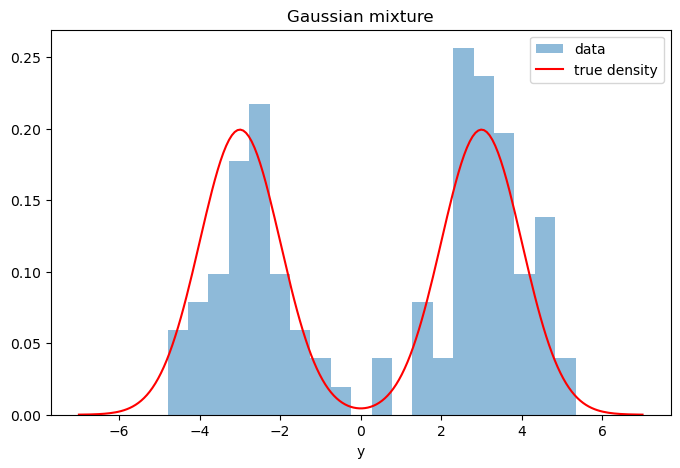

Component counts: [43 57]
True μ: [-3.  3.]


In [88]:
n, K = 100, 2
mu_true = np.array([-3.0, 3.0])  # well-separated means

# simulate: pick component then sample from it
z = np.random.randint(0, K, size=n)    # latent component assignment
y = np.random.normal(mu_true[z], 1)        # sample from chosen component

# visualize
x_grid = np.linspace(-7, 7, 200)
mixture_density = sum(1/K * np.exp(-0.5*(x_grid - mu)**2) / np.sqrt(2*np.pi)
                      for mu in mu_true)

plt.hist(y, bins=20, density=True, alpha=0.5, label='data')
plt.plot(x_grid, mixture_density, 'r-', label='true density')
plt.xlabel('y')
plt.title('Gaussian mixture')
plt.legend()
plt.show()

print(f"Component counts: {np.bincount(z)}")
print(f"True μ: {mu_true}")

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 10.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
With N(0, 10²) prior on μ<sub>k</sub>, implement a <b>Gibbs sampler</b> for the posterior of (μ<sub>1</sub>, μ<sub>2</sub>). Hint: introduce latent variables z<sub>i</sub>.
</div>

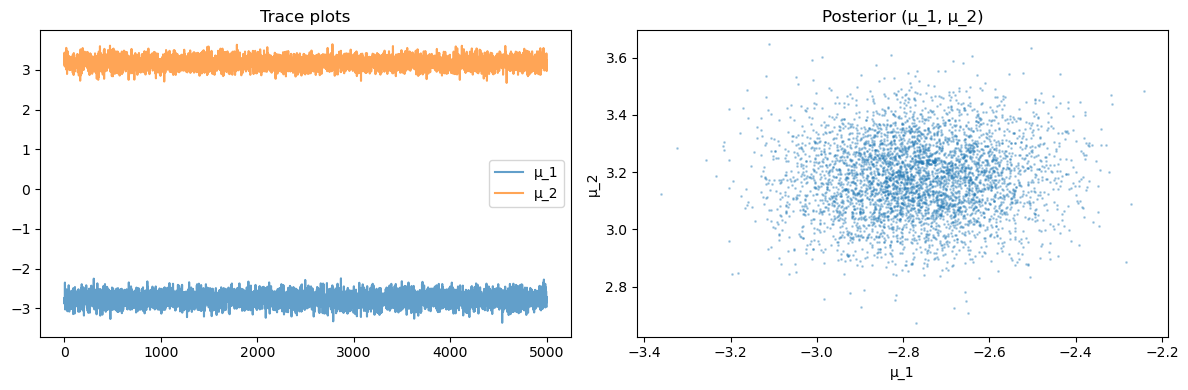

In [89]:
from scipy.stats import norm

def gibbs_mixture(y, K, N=5000, prior_var=100):
    n = len(y)
    mu = np.array([-1.0, 1.0])  # initialization
    z = np.zeros(n, dtype=int)
    
    samples_mu = np.zeros((N, K))
    
    # z will be the katent variable introduced here
    for t in range(N):
        # sample z_i | rest ~ Categorical
        for i in range(n):
            # unnormalized probabilities for each component
            probs = np.array([norm.pdf(y[i], mu[k], 1) for k in range(K)])
            probs /= probs.sum()
            z[i] = np.random.choice(K, p=probs)
        
        # sample mu_k | rest ~ Normal (conjugate)
        for k in range(K):
            idx = (z == k)
            n_k = idx.sum()
            if n_k == 0:
                mu[k] = np.random.normal(0, np.sqrt(prior_var))
            else:
                post_var = 1 / (n_k + 1/prior_var)
                post_mean = post_var * y[idx].sum()
                mu[k] = np.random.normal(post_mean, np.sqrt(post_var))
        
        samples_mu[t] = mu
    
    return samples_mu

burn_in = 500
samples_mu = gibbs_mixture(y, K=2, N=5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axes[0].plot(samples_mu[:, k], alpha=0.7, label=f'μ_{k+1}')
axes[0].set_title('Trace plots'); axes[0].legend()

axes[1].scatter(samples_mu[burn_in:, 0], samples_mu[burn_in:, 1], s=1, alpha=0.3)
axes[1].set_xlabel('μ_1'); axes[1].set_ylabel('μ_2')
axes[1].set_title('Posterior (μ_1, μ_2)')
plt.tight_layout()
plt.show()

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 10.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
The likelihood is <b>permutation-invariant</b>. Do a scatter plot of (μ<sub>1</sub>, μ<sub>2</sub>) from the Gibbs sampler. Try different settings and discuss.
</div>

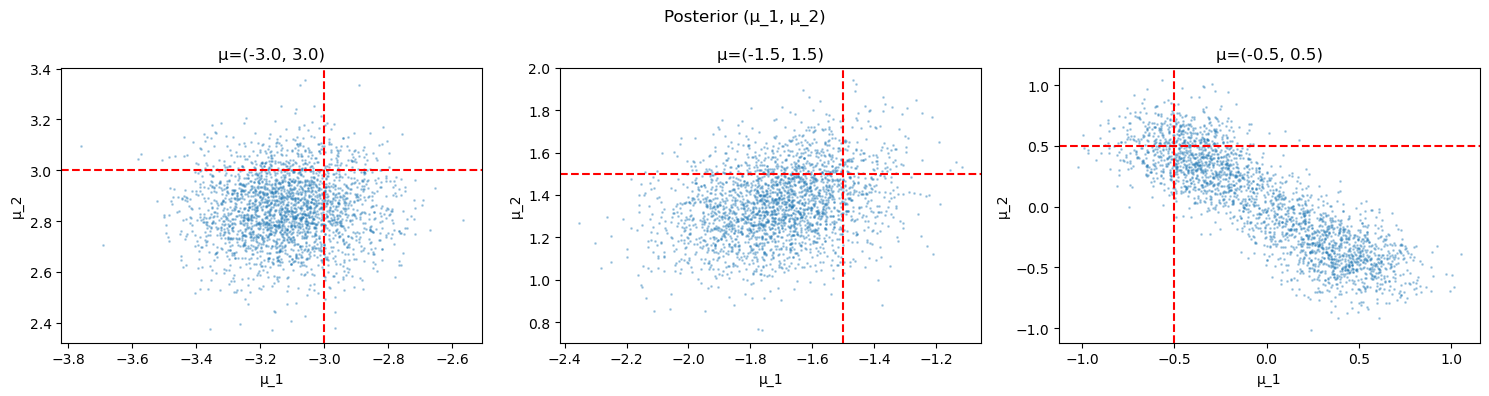

In [90]:
settings = [
    (-3.0,  3.0),   # well separated which implies that the sampler stays in one mode
    (-1.5,  1.5),   # moderately separated
    (-0.5,  0.5),   # close which will induce label switching (as expected)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (mu1, mu2) in zip(axes, settings):
    mu_true_local = np.array([mu1, mu2])
    z_local = np.random.choice(2, size=100, p=[0.5, 0.5])
    y_local = np.random.normal(mu_true_local[z_local], 1)
    
    s = gibbs_mixture(y_local, K=2, N=3000)
    ax.scatter(s[500:, 0], s[500:, 1], s=1, alpha=0.3)
    ax.axvline(mu1, color='r', linestyle='--')
    ax.axhline(mu2, color='r', linestyle='--')
    ax.set_xlabel('μ_1'); ax.set_ylabel('μ_2')
    ax.set_title(f'μ=({mu1}, {mu2})')

plt.suptitle('Posterior (μ_1, μ_2)')
plt.tight_layout()
plt.savefig('img/label_switching.png', dpi=150, bbox_inches='tight')
plt.show()

# the red cross gives the true alue of mu_1 and mu_2
# in the left and in the middle, single tight cluster (= sampler never swaps labels)
# in the right, 2 distinct clusters which show the label switching

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 10.4</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Generalise to <b>unknown variances</b> (inverse-Gaussian prior) and <b>unknown mixing weights</b> (Beta for K=2, Dirichlet for K≥3).
</div>

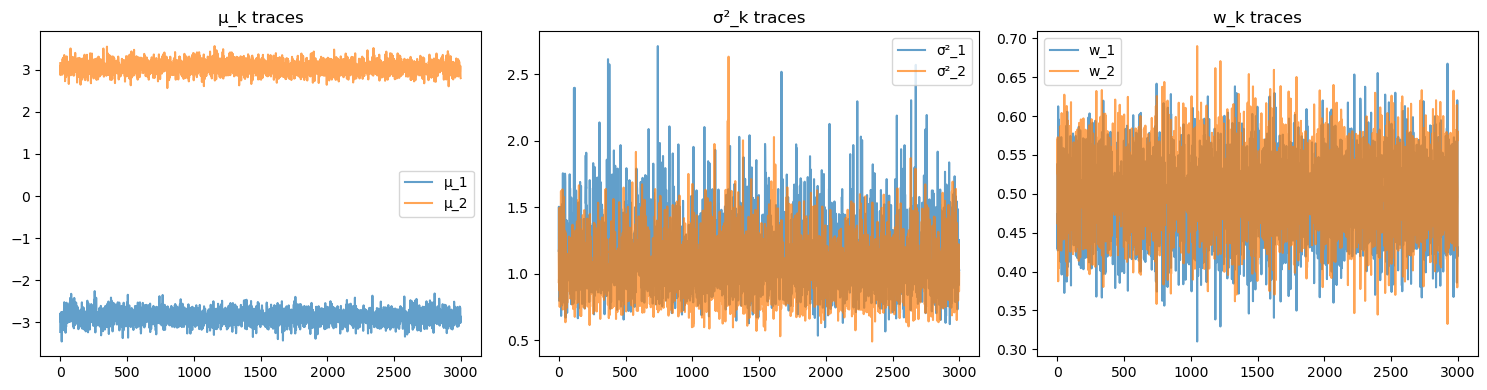

Posterior mean μ:  [-2.875  3.064]
Posterior mean σ²: [1.147 1.026]
Posterior mean w:  [0.492 0.508]


In [63]:
from scipy.stats import invgamma, dirichlet

def gibbs_mixture_full(y, K, N=5000, prior_var=100, a_sig=2, b_sig=1, alpha_0=1):
    n = len(y)
    mu = np.linspace(-2, 2, K)
    sigma2 = np.ones(K)
    w = np.ones(K) / K
    z = np.zeros(n, dtype=int)

    samples_mu     = np.zeros((N, K))
    samples_sigma2 = np.zeros((N, K))
    samples_w      = np.zeros((N, K))

    for t in range(N):
        # sample z_i | rest ~ Categorical(w_k * phi(y_i; mu_k, sigma2_k))
        probs = np.array([w[k] * norm.pdf(y, mu[k], np.sqrt(sigma2[k]))
                          for k in range(K)]).T       # shape (n, K)
        probs /= probs.sum(axis=1, keepdims=True)
        z = np.array([np.random.choice(K, p=probs[i]) for i in range(n)])

        for k in range(K):
            idx = (z == k)
            n_k = idx.sum()
            y_k = y[idx]

            # sample mu_k | rest ~ Normal (conjugate)
            if n_k == 0:
                mu[k] = np.random.normal(0, np.sqrt(prior_var))
            else:
                post_var  = 1 / (n_k/sigma2[k] + 1/prior_var)
                post_mean = post_var * (y_k.sum() / sigma2[k])
                mu[k] = np.random.normal(post_mean, np.sqrt(post_var))

            # sample sigma2_k | rest ~ Inv-Gamma (conjugate)
            a_post = a_sig + n_k/2
            b_post = b_sig + 0.5 * ((y_k - mu[k])**2).sum() if n_k > 0 else b_sig
            sigma2[k] = invgamma.rvs(a_post, scale=b_post)

        # sample w | rest ~ Dirichlet (conjugate)
        counts = np.array([( z == k).sum() for k in range(K)])
        w = np.random.dirichlet(alpha_0 + counts)

        samples_mu[t]     = mu
        samples_sigma2[t] = sigma2
        samples_w[t]      = w

    return samples_mu, samples_sigma2, samples_w

burn_in = 500
mu_s, sig_s, w_s = gibbs_mixture_full(y, K=2, N=3000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k in range(2):
    axes[0].plot(mu_s[:, k], alpha=0.7, label=f'μ_{k+1}')
    axes[1].plot(sig_s[:, k], alpha=0.7, label=f'σ²_{k+1}')
    axes[2].plot(w_s[:, k], alpha=0.7, label=f'w_{k+1}')

for ax, title in zip(axes, ['μ_k traces', 'σ²_k traces', 'w_k traces']):
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

print(f"Posterior mean μ:  {mu_s[burn_in:].mean(axis=0).round(3)}")
print(f"Posterior mean σ²: {sig_s[burn_in:].mean(axis=0).round(3)}")
print(f"Posterior mean w:  {w_s[burn_in:].mean(axis=0).round(3)}")


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">11 &nbsp;·&nbsp; Discretization Error in Option Pricing</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Black-Scholes process: &nbsp; <b>S(t) = exp{ (μ − σ²/2)t + σW<sub>t</sub> }</b>
  <br>European put price: &nbsp; <b>V = E[ e<sup>−rT</sup> (K − S(T))<sup>+</sup> ]</b> &nbsp; with T=1, r=0.02, μ=0.5, σ=0.5, K=2.
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 11.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Let (W<sub>t</sub>) be a Wiener process. Derive the distribution of <b>W<sub>t</sub> | W<sub>a</sub>, W<sub>b</sub></b> for a ≤ t ≤ b.
</div>

Since $(W_t)$ is a Gaussian process, $(W_a, W_t, W_b)$ is jointly Gaussian, so the conditional is also Gaussian.

Covariances: $\text{Cov}(W_s, W_t) = \min(s,t)$, so with $a \leq t \leq b$:

$$\Sigma_{XX} = t, \quad \Sigma_{XY} = (a,\ t), \quad \Sigma_{YY} = \begin{pmatrix} a & a \ a & b \end{pmatrix}$$

$$\Sigma_{YY}^{-1} = \frac{1}{a(b-a)}\begin{pmatrix} b & -a \ -a & a \end{pmatrix}$$

Conditional mean:

$$\mu_{X|Y} = \Sigma_{XY}\Sigma_{YY}^{-1}\begin{pmatrix}W_a \ W_b\end{pmatrix} = \frac{1}{b-a}(b-t,\ t-a)\begin{pmatrix}W_a \ W_b\end{pmatrix}$$

$$= \frac{(b-t)W_a + (t-a)W_b}{b-a}$$

which is basically a linear interpolation between $W_a$ and $W_b$.

Conditional variance:

$$\sigma^2_{X|Y} = t - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX} = t - \frac{a(b-t)+t(t-a)}{b-a} = \frac{(t-a)(b-t)}{b-a}$$

Hence, this gives us the result: 

$$\boxed{W_t \mid W_a, W_b \sim \mathcal{N}\left(\frac{(b-t)W_a + (t-a)W_b}{b-a},\ \frac{(t-a)(b-t)}{b-a}\right)}$$

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 11.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Use <b>Monte Carlo</b> to approximate V.
</div>

In [65]:
N = 100000
T, r, mu, sigma, K_strike = 1, 0.02, 0.5, 0.5, 2

# S(T) = exp((mu - sigma^2/2)*T + sigma*W_T) with W_T ~ N(0,T)
W_T = np.random.normal(0, np.sqrt(T), N)
S_T = np.exp((mu - sigma**2/2)*T + sigma*W_T)

# put payoff
payoff = np.maximum(K_strike - S_T, 0)
V_mc = np.exp(-r*T) * payoff.mean()
std  = np.exp(-r*T) * payoff.std() / np.sqrt(N)

print(f"MC estimate: {V_mc:.4f} ± {std:.4f}")

MC estimate: 0.5518 ± 0.0015


<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 11.3</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Treating S(t) as unknown, build an <b>iterative algorithm</b> that gradually refines the discretization step, recycling simulations from the previous step.
</div>

In [ ]:
def refine_put(k0=3, N=10000, max_levels=10, alpha=2):
    T, r, mu, sigma, K_strike = 1, 0.02, 0.5, 0.5, 2

    # initialize: 2^k0 steps
    n_steps = 2**k0
    dt = T / n_steps
    times = np.arange(1, n_steps+1) * dt

    # simulate initial Brownian path
    dW = np.random.normal(0, np.sqrt(dt), (N, n_steps))
    W  = np.cumsum(dW, axis=1)   # shape (N, n_steps)

    def estimate_V(W, times):
        # Euler scheme
        t_full = np.concatenate([[0], times])
        W_full = np.concatenate([np.zeros((N,1)), W], axis=1)
        S = np.ones(N)
        for i in range(len(times)):
            dt_i = t_full[i+1] - t_full[i]
            dW_i = W_full[:, i+1] - W_full[:, i]
            S    = S + mu*S*dt_i + sigma*S*dW_i
        payoff = np.maximum(K_strike - S, 0)
        disc   = np.exp(-r*T)
        return disc*payoff.mean(), disc*payoff.std()/np.sqrt(N)

    V_prev, std_prev = estimate_V(W, times)
    print(f"k=0 ({n_steps} steps): V = {V_prev:.4f} ± {alpha*std_prev:.4f}")

    for k in range(1, max_levels+1):
        # insert 2^(k+k0-1) midpoints via Brownian bridge
        t_full = np.concatenate([[0], times])
        W_full = np.concatenate([np.zeros((N,1)), W], axis=1)
        new_times, new_W = [], []

        for i in range(len(times)):
            a, b   = t_full[i], t_full[i+1]
            t_mid  = (a + b) / 2
            Wa, Wb = W_full[:, i], W_full[:, i+1]
            # Q 11.1 Brownian bridge formula
            cond_mean = ((b-t_mid)*Wa + (t_mid-a)*Wb) / (b-a)
            cond_var  = (t_mid-a)*(b-t_mid) / (b-a)
            W_mid = np.random.normal(cond_mean, np.sqrt(cond_var))
            new_times += [t_mid, b]
            new_W.append(np.column_stack([W_mid, Wb]))

        times  = np.array(new_times)
        W      = np.concatenate(new_W, axis=1)
        n_steps = len(times)

        V_curr, std_curr = estimate_V(W, times)
        CI_prev = alpha * std_prev
        CI_curr = alpha * std_curr
        overlap = abs(V_curr - V_prev) < CI_prev + CI_curr

        print(f"k={k} ({n_steps} steps): V = {V_curr:.4f} ± {CI_curr:.4f} | "
              f"{'CONVERGED — stop' if overlap else 'continue...'}")

        if overlap:
            print(f"\nFinal estimate: V = {V_curr:.4f} ± {CI_curr:.4f}")
            break

        # CIs too wide to compare → increase N
        if CI_curr > 5 * abs(V_curr - V_prev):
            N *= 2
            print(f"  → CIs too wide, increasing N to {N}")

        V_prev, std_prev = V_curr, std_curr

refine_put(k0=2, N=10000)

k=0 (4 steps): V = 0.5369 ± 0.0093
k=1 (8 steps): V = 0.5414 ± 0.0093 | CONVERGED — stop

Final estimate: V = 0.5414 ± 0.0093


<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">12 &nbsp;·&nbsp; Cross-Entropy Method</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Rosenbrock function: &nbsp; <b>S(x) = Σ<sub>i=1</sub><sup>d</sup> [ 100(x<sub>i+1</sub> − x<sub>i</sub>²)² + (x<sub>i</sub> − 1)² ]</b>
  <br>Global minimum: x* = (1, …, 1).
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Propose a <b>Cross-Entropy (CE) algorithm</b> to find the global minimum of any S: ℝ<sup>d</sup> → ℝ. Program it and apply it to the Rosenbrock function for different values of d.
</div>

d=2: x* ≈ [1.    1.001], S(x*)=0.000000
d=5: x* ≈ [0.755 0.57  0.328 0.112 0.012], S(x*)=1.484221
d=10: x* ≈ [ 0.679  0.464  0.219  0.056  0.013  0.01   0.01   0.01   0.01  -0.   ], S(x*)=6.839935


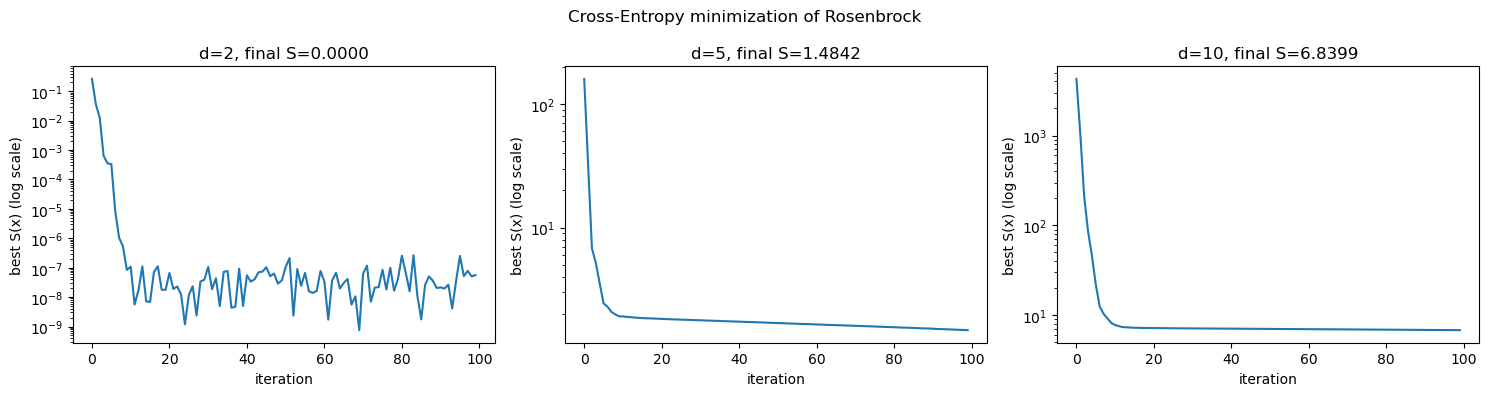

In [68]:
def rosenbrock(x):
    x = np.array(x)
    return sum(100*(x[i+1] - x[i]**2)**2 + (x[i]-1)**2 
               for i in range(len(x)-1))

def cross_entropy_min(d, N=1000, rho=0.1, max_iter=100, tol=1e-6):
    # initialize distribution
    mu    = np.zeros(d)
    Sigma = 10 * np.eye(d)   # wide initial distribution
    
    history = []
    
    for t in range(max_iter):
        # sample N points first
        X = np.random.multivariate_normal(mu, Sigma, N)
        
        # evaluate S on all samples
        scores = np.array([rosenbrock(x) for x in X])
        
        # select elite samples (those with the lowest rho*N scores)
        n_elite = max(int(rho * N), 2)
        elite_idx = np.argsort(scores)[:n_elite]
        elite = X[elite_idx]
        
        # update distribution (MLE on elite)
        mu_new    = elite.mean(axis=0)
        Sigma_new = np.cov(elite.T) + 1e-6*np.eye(d)  # regularize
        
        best = scores[elite_idx[0]]
        history.append(best)
        
        # check convergence
        if np.linalg.norm(mu_new - mu) < tol:
            print(f"Converged at iteration {t+1}")
            break
        
        mu, Sigma = mu_new, Sigma_new
    
    return mu, best, history

# finally apply to Rosenbrock for different d
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, [2, 5, 10]):
    x_opt, best, history = cross_entropy_min(d, N=1000, rho=0.1)
    ax.semilogy(history)
    ax.set_title(f'd={d}, final S={best:.4f}')
    ax.set_xlabel('iteration')
    ax.set_ylabel('best S(x) (log scale)')
    print(f"d={d}: x* ≈ {x_opt.round(3)}, S(x*)={best:.6f}")

plt.suptitle('Cross-Entropy minimization of Rosenbrock')
plt.tight_layout()
plt.show()

<div style="background-color:#CC0000; color:white; padding:12px 20px; border-radius:6px 6px 0 0; margin-top:40px;">
  <h2 style="margin:0; font-size:1.4em;">13 &nbsp;·&nbsp; ABC</h2>
</div>
<div style="background-color:#FDF0F2; color:#000000; border:1.5px solid #DD3333; border-top:none; border-radius:0 0 6px 6px; padding:16px 20px; margin-bottom:4px;">
  Network model with n individuals, X<sub>ij</sub> ∈ {0,1}:
  <p style="text-align:center;"><b>p(x|θ) = 1/Z(θ) · exp{ θ<sup>T</sup> S(x) }</b></p>
  where S(x) = (Σ x<sub>ij</sub>, number of individuals with ≥3 connections).
</div>

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 13.1</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Propose and implement an algorithm to <b>simulate from the model</b> for a given θ. Use it to simulate a network of size n=20.
</div>

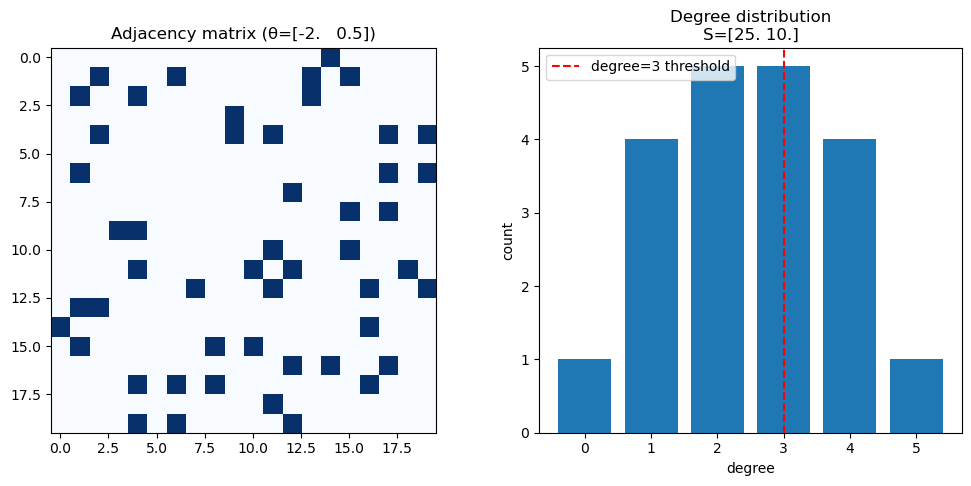

S(x) = [25. 10.] (edges, nodes with deg≥3)


In [70]:
def compute_S(x):
    # S1: total edges, S2: number of nodes with degree >= 3
    S1 = x.sum() // 2  # each edge counted twice
    degrees = x.sum(axis=1)
    S2 = (degrees >= 3).sum()
    return np.array([S1, S2], dtype=float)

def delta_S(x, i, j):
    # change in S when flipping edge (i,j): compute S with xij=1 minus S with xij=0
    x1 = x.copy(); x1[i,j] = x1[j,i] = 1
    x0 = x.copy(); x0[i,j] = x0[j,i] = 0
    return compute_S(x1) - compute_S(x0)

def gibbs_ergm(theta, n=20, N_iter=2000):
    # initialize random adjacency matrix
    x = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i+1, n):
            x[i,j] = x[j,i] = np.random.randint(2)
    
    edges = [(i,j) for i in range(n) for j in range(i+1, n)]
    
    for _ in range(N_iter):
        for i, j in edges:
            dS = delta_S(x, i, j)
            p  = sigmoid(theta @ dS)
            x[i,j] = x[j,i] = np.random.binomial(1, p)
    
    return x

# simulate 
theta = np.array([-2.0, 0.5])  
x = gibbs_ergm(theta, n=20, N_iter=500)

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(x, cmap='Blues')
axes[0].set_title(f'Adjacency matrix (θ={theta})')

# degree distribution
degrees = x.sum(axis=1)
axes[1].bar(range(max(degrees)+1),
            [( degrees==k).sum() for k in range(max(degrees)+1)])
axes[1].axvline(3, color='r', linestyle='--', label='degree=3 threshold')
axes[1].set_xlabel('degree')
axes[1].set_ylabel('count')
axes[1].set_title(f'Degree distribution\nS={compute_S(x)}')
axes[1].legend()
plt.show()

print(f"S(x) = {compute_S(x)} (edges, nodes with deg≥3)")

<div style="background-color:#AA0000; color:white; padding:8px 20px; border-radius:4px; display:inline-block; margin-top:12px;">
  <b>Q 13.2</b>
</div>
<div style="background-color:#FDF0F2; color:#000000; border-left:4px solid #DD3333; padding:10px 16px; margin-top:4px; border-radius:0 4px 4px 0;">
Assume θ is unknown. Propose an <b>ABC algorithm</b> to estimate θ based on one or several networks (uniform prior on each component of θ).
</div>

Edges: 8
S(x_obs) = [27. 12.]
Observed S(x_obs) = [27. 12.]
ε=15: done, acceptance=0.305
ε=10: done, acceptance=0.517
ε=6: done, acceptance=0.446
ε=3: done, acceptance=0.261
ε=2: done, acceptance=0.129
Posterior mean: [-1.676  1.835]
True θ:         [-1.5  1. ]


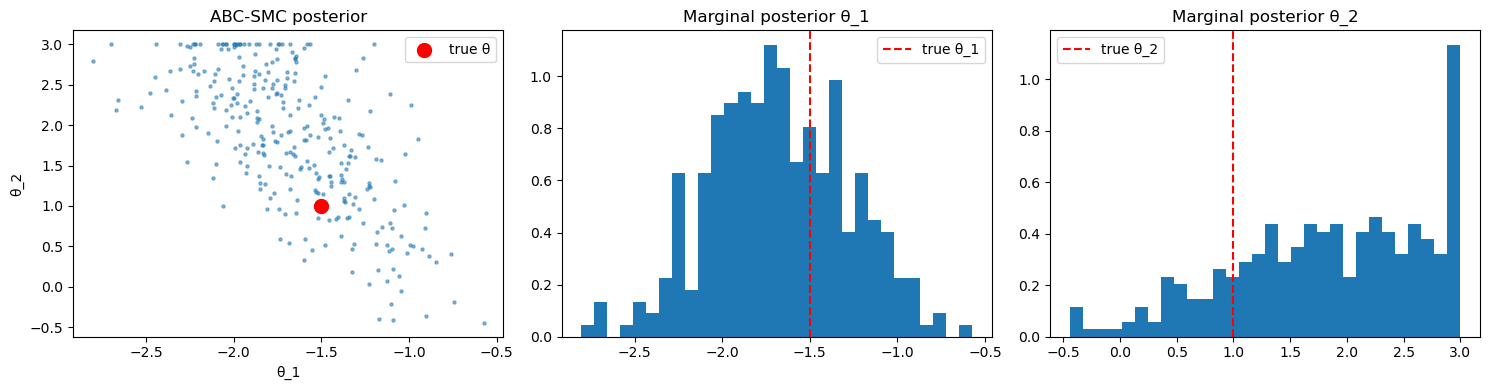

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_S(x):
    S1 = x.sum() // 2
    degrees = x.sum(axis=1)
    S2 = (degrees >= 3).sum()
    return np.array([S1, S2], dtype=float)

def gibbs_ergm(theta, n=12, N_iter=10000):
    x = np.zeros((n, n), dtype=int)  # start empty
    edges = [(i,j) for i in range(n) for j in range(i+1, n)]

    for _ in range(N_iter):
        i, j = edges[np.random.randint(len(edges))]
        
        # degree w/o edge (i,j)
        deg0_i = x.sum(axis=1)[i] - x[i,j]
        deg0_j = x.sum(axis=1)[j] - x[i,j]
        
        # delta S = S(x^{ij=1}) - S(x^{ij=0}), always positive for S1
        dS1 = 1
        dS2 = (int(deg0_i + 1 >= 3) - int(deg0_i >= 3) +
               int(deg0_j + 1 >= 3) - int(deg0_j >= 3))
        
        p = sigmoid(theta[0]*dS1 + theta[1]*dS2)
        x[i,j] = x[j,i] = np.random.binomial(1, p)

    return x

# verify
x_test = gibbs_ergm(np.array([-3.0, 1.0]), n=12, N_iter=10000)
print(f"Edges: {x_test.sum()//2}")  

     

def abc_smc(x_obs, n=12, N_particles=300, epsilons=[15, 10, 6, 3, 2]):
    S_obs = compute_S(x_obs)

    # initialize from prior
    particles = np.random.uniform(-3, 3, (N_particles, 2))

    for eps in epsilons:
        new_particles = []
        attempts = 0
        while len(new_particles) < N_particles:
            idx = np.random.randint(N_particles)
            theta = particles[idx] + np.random.normal(0, 0.5, 2)
            theta = np.clip(theta, -3, 3)
            x_sim = gibbs_ergm(theta, n=n, N_iter=500)
            if np.linalg.norm(compute_S(x_sim) - S_obs) <= eps:
                new_particles.append(theta)
            attempts += 1
        particles = np.array(new_particles)
        print(f"ε={eps}: done, acceptance={N_particles/attempts:.3f}")

    return particles

# generate observed network
n = 15
theta_true = np.array([-1.5, 1.0])  
x_obs = gibbs_ergm(theta_true, n=n, N_iter=10000)
print(f"S(x_obs) = {compute_S(x_obs)}")  

S_obs = compute_S(x_obs)
print(f"Observed S(x_obs) = {S_obs}")

# run ABC-SMC
accepted = abc_smc(x_obs, n=n, N_particles=300, epsilons=[15, 10, 6, 3, 2])
print(f"Posterior mean: {accepted.mean(axis=0).round(3)}")
print(f"True θ:         {theta_true}")

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(accepted[:,0], accepted[:,1], s=5, alpha=0.5)
axes[0].scatter(*theta_true, color='r', s=100, label='true θ', zorder=5)
axes[0].set_xlabel('θ_1'); axes[0].set_ylabel('θ_2')
axes[0].set_title('ABC-SMC posterior')
axes[0].legend()

axes[1].hist(accepted[:,0], bins=30, density=True)
axes[1].axvline(theta_true[0], color='r', linestyle='--', label='true θ_1')
axes[1].set_title('Marginal posterior θ_1')
axes[1].legend()

axes[2].hist(accepted[:,1], bins=30, density=True)
axes[2].axvline(theta_true[1], color='r', linestyle='--', label='true θ_2')
axes[2].set_title('Marginal posterior θ_2')
axes[2].legend()

plt.tight_layout()
plt.show()

# As we can see, ABC successfully identifies θ_1 (edge density parameter) but struggles with θ_2 (degree threshold parameter).
# It could be because the summary statistic S2 is not sufficiently informative to distinguish between different values of θ_2. 
# Or it could be that the sampler / algorithm written here isn't optimized enough.